# EDIS 8100 · Week 7 · Self-Regulated Learning Traces Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Our guest this week is Conrad Borchers of Vanderbilt University, who joins us for the last hour of the session and is a coauthor of one of this week's required readings.

**There is no notebook block in class this week.** The session is an opening, the student-led discussion hour, a preparation block for the guest, a break, and then the guest. This notebook is yours to work through outside class, at whatever pace suits you.

We open a real tutoring log: **1,893,105 timestamped actions** left by **500 people** using a commercial tutoring app on phones and in browsers over roughly fifteen months.

The week's question is the one Winne poses. Self-regulated learning is not directly observable, so what a log offers is recorded events: a button was pressed, a screen was opened, a screen was closed, and each event carries a millisecond stamp.

Three ideas run through the session:

1. **Order matters.** A frequency table sets aside the one thing a sequence has.
2. **Timing separates things that counting cannot.** Two learners with identical counts may be doing quite different things, and the timestamps are often the only column that can tell them apart.
3. **A pattern in a log is not by itself evidence about a mind.** Two of the patterns below look like learner behavior, and the timing is consistent with the application, not the learner, generating them.

### What I hope you leave with

1. A way of reading the action vocabulary of a real tutor log out of the file itself, and of saying which parts of a learner's profile are about the learner and which are set by the software.
2. Being able to cut a continuous stream into sessions using a stated gap rule, and to report a sensitivity check showing how far the headline moves when that rule changes.
3. A feel for reading the order in which answering and explanation viewing occur, and for noticing when the order is set by the interface rather than chosen by the person.
4. Using inter-action timing to separate a screen that was displayed from a screen that was read, and being able to say what the clock still cannot tell us.
5. Recognizing a logging artifact: a measure that appears to be about a learner's choices and turns out to be about a logging convention.

None of these is a coding objective.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**. Every cell assumes the ones above it have already run.
- This runs on a temporary machine in the cloud, working on a copy of a published file. If something looks wrong, `Runtime > Restart session and run all` in Colab, or `Kernel > Restart & Run All` in Jupyter, resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without editing anything and nothing will be missing. Changing one and re-running shows what that choice was doing to the result, which is why it is marked.
- The section marked **Going further** at the end is optional.
- Most output is printed as a small table rather than left to be eyeballed. The tables are where the argument is.

### The route

This notebook is worked through outside class rather than opened in class, so the route below is
for working alone. It says what to do first when the time available is short.

| | Sections | What it is for |
|---|---|---|
| **CORE, about 55 to 60 minutes** | Where this data came from, Setup, 1, 1.1, 1.2, 2, 3, 3.1 with Your turn 2, 4, 5, and 7 through its **Let's look at the output** | Provenance and license, the grain and the vocabulary, the audit of the download, the profile and its structural ties, the session rule and its sensitivity, the transition matrix, the submit-to-explanation latency, and the dwell distribution with its interval. Then the Reflection prompts on Winne and on Viberg, Khalil and Baars |
| **IF TIME** | 6 with Your turn 3, 7.1, 7.2, Your turn 1, Your turn 4, the Zhang, Borchers and Barany prompt, the prompt that reaches back to Week 3, and A question for our guest | The concentration comparison and its sample-size correction, the within-learner dwell comparison and its breakdown, time to the first recorded response, the other threshold exercises, and the question for the preparation block |
| **EXPLORE LATER** | Going further 1 to 4 | Several learners at once, the twelve-point session sweep, the concentration sweep, and the bottom-decile overlap grid |


**Coding expertise is not assumed here.** Nothing in this notebook asks you to write code from scratch. Your attention is better spent on what the code is doing to the data and on what the output might mean. Questions are welcome at any point, including questions about a single line of code.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to read the code the way you read a methods section: you are checking what was done to the data, not memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in `df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`, `.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line does not make sense, please ask.

**Nothing from this notebook is collected.** What the interpretation cells invite is a reading of the output: what the method can see, what it cannot, and what the numbers might mean.

## Where this data came from

**Dataset.** **EdNet KT3**, restricted to a 500-user extract prepared for this course. EdNet is the released log of **Santa**, a commercial multi-platform tutoring service in South Korea for the **TOEIC** English proficiency test. KT3 is the action-level release: one row per interface event, with seven columns. The timestamp in milliseconds, what kind of event it was, which item it happened on, which study mode the app was in, which option was chosen if the event was an answer, which platform the person was using, and who they were. EdNet's documentation states that the timestamps were shifted by fixed values for security, so the calendar dates and clock times printed in this notebook should be read as approximate; within-learner intervals, which every measure here uses, are unaffected if the shift is constant within a learner (riiid/ednet README).

**Who collected it, in one sentence.** Riiid, the company that operates Santa, logged every interface event its own product generated as a by-product of running the service, and its research group then anonymized and released four nested versions of that log, KT1 through KT4, so that researchers with no access to a commercial tutor could work on real interaction data at scale.

**License.** **CC BY-NC 4.0.** The license permits use, sharing, and adaptation **with attribution and for non-commercial purposes only**. Anything built on this file in this course stays inside this course, which rules out a product, a consulting deliverable, or a paid workshop.

**Citation, APA 7:**

> Choi, Y., Lee, Y., Shin, D., Cho, J., Park, S., Lee, S., Baek, J., Bae, C., Kim, B., & Heo, J. (2020). EdNet: A large-scale hierarchical dataset in education. In *Artificial intelligence in education (AIED 2020)*, Lecture Notes in Computer Science 12164 (pp. 69-73). Springer.

**Who is in it.** People in South Korea preparing for a high-stakes English proficiency test (Choi et al., 2020), on a commercial app with a free daily allowance and paid access (riiid/ednet README) and, for the majority of the rows here, on a phone. Choi and colleagues describe the service, not these 500 individuals; the extract itself carries **no age, no gender, no location, no score, and no name**. These are people doing test preparation, and the file records nothing about the time they had.

**What the extract omits.** Identity is gone: every person is an integer with a `u` in front of it. Item content is gone: a question is `q4142` and nothing more, so we cannot see what was asked or judge whether it was a fair item. **And the answer key is gone.** KT3 records which option a person chose and never records which option was correct. That absence rules out any analysis of correctness, and Section 6 returns to why the absence turns out to be useful.

**One sentence, for when someone asks.** *"An anonymized 500-user extract of EdNet KT3, the released interaction log of the Santa TOEIC tutor in South Korea, collected by Riiid's own product systems and published by Choi and colleagues under CC BY-NC 4.0."*

## Setup

**Run the cell below.** It downloads this week's single file from the course dataset repository. It is about 14 MB compressed and usually arrives in a second or two.

If the runtime has no internet connection, the cell says so in plain English instead of a long error traceback.

**On size.** Loaded with sensible column types the whole file is roughly 225 MB in memory, and every computation in this notebook finishes in seconds. **We keep all 1,893,105 rows.** Nothing is sampled, nothing is thinned. Where a step later drops rows, it drops them in view with a count and a reason.

In [1]:
%matplotlib inline

# SETUP CELL. Imports, plot defaults, and this week's download. Run it once.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.30
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.size'] = 10
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)

# Okabe and Ito colorblind-safe palette. No red against green anywhere in this notebook.
BLUE, ORANGE, VERMILLION = '#0072B2', '#E69F00', '#D55E00'
GREEN, PURPLE, SKY, GREY, BLACK = '#009E73', '#CC79A7', '#56B4E9', '#999999', '#333333'

REPO = 'github.com/HakeoungLee/edis8100-datasets'
URL = ('https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/'
       'main/ednet-kt3-500/actions.csv.gz')

try:
    actions = pd.read_csv(URL, dtype={'action_type': 'category', 'source': 'category',
                                      'platform': 'category', 'user_answer': 'category'})
except Exception as err:
    print('=' * 78)
    print('The data did not download, so nothing below this cell will work yet.')
    print()
    print('This notebook reads one file from the course dataset repository:')
    print('    ' + REPO + ', folder ednet-kt3-500, file actions.csv.gz')
    print('    ' + URL)
    print()
    print('The usual cause is no internet connection in this runtime. Check your')
    print('connection, then use Runtime > Restart session and run all. If the repository')
    print('itself is unreachable, tell Dr. Lee: the link above is the one to send.')
    print()
    print('Technical detail, for the record: %s: %s' % (type(err).__name__, err))
    print('=' * 78)
    raise SystemExit('Download failed. The message above says what to do.') from None

print('actions.csv.gz arrived from ' + REPO + ' (folder ednet-kt3-500).')
print()
print('   %s rows x %d columns' % (format(len(actions), ','), actions.shape[1]))
print('   %d learners' % actions['user_id'].nunique())
print('   about %.0f MB in memory' % (actions.memory_usage(deep=True).sum() / 1e6))
print('   columns: ' + ', '.join(actions.columns))
print()
print('Real, published, CC BY-NC 4.0 data. Choi and colleagues (2020), EdNet KT3.')
print('Non-commercial use only. Nothing built on this file leaves this course.')

actions.csv.gz arrived from github.com/HakeoungLee/edis8100-datasets (folder ednet-kt3-500).

   1,893,105 rows x 7 columns
   500 learners


   about 225 MB in memory
   columns: timestamp, action_type, item_id, source, user_answer, platform, user_id

Real, published, CC BY-NC 4.0 data. Choi and colleagues (2020), EdNet KT3.
Non-commercial use only. Nothing built on this file leaves this course.


## 1. One row, and the vocabulary of this log

Before anything else: what is one row, and what is the vocabulary?

One row is **one interface event by one person at one millisecond**. That is the grain. It is not a session, not a question, not a learner.

The vocabulary is not documented in the file. It has to be read out of the file. Two columns carry it:

- `action_type`: what happened, in four values.
- `item_id`: what it happened to. The **first letter** is the item type and the rest is a number.

**Run the cell below.** It prints the raw head and then crosses those two columns against each other.

In [2]:
# Sort once, and keep this ordering for the whole notebook.
# When the unit of analysis is a sequence, order is not a display preference.
actions = actions.sort_values(['user_id', 'timestamp'], kind='mergesort').reset_index(drop=True)

# The first letter of item_id is the item type; the rest is the item number.
actions['item_kind'] = actions['item_id'].str[0]
actions['item_num'] = actions['item_id'].str[1:]

# One readable label per event: what happened, to what kind of thing.
actions['event'] = actions['action_type'].astype(str) + '_' + actions['item_kind']

print('--- the first 12 rows, exactly as they arrived ---')
print(actions.head(12).drop(columns=['event', 'item_kind', 'item_num']).to_string(index=False))
print()
print('--- action_type against item_kind (counts of rows) ---')
print(pd.crosstab(actions['action_type'], actions['item_kind']).to_string())
print()
print('Item kinds present:', sorted(actions['item_kind'].unique()))
for k, n in actions.groupby('item_kind')['item_id'].nunique().items():
    print('   %s : %6s distinct items' % (k, format(n, ',')))
print()
print('user_answer is filled in on %s rows and blank on %s.'
      % (format(int(actions['user_answer'].notna().sum()), ','),
         format(int(actions['user_answer'].isna().sum()), ',')))
print('It is filled in on exactly the "respond" rows:',
      bool(actions['user_answer'].notna().sum() == (actions['action_type'] == 'respond').sum()))
print()
print('There is no column for whether an answer was right. Check for yourself:')
print('   columns present:', list(actions.columns[:7]))

print()
print('--- platform and study mode, printed once so later sentences have a source ---')
for p, n in actions['platform'].value_counts().items():
    print('   platform %-7s %11s rows  (%.1f%% of the file)'
          % (p, format(int(n), ','), 100 * n / len(actions)))
plat_by_learner = pd.crosstab(actions['user_id'], actions['platform'].astype(str)) > 0
print('   learners recorded on mobile only: %d,  on web only: %d,  on both: %d'
      % (int((plat_by_learner['mobile'] & ~plat_by_learner['web']).sum()),
         int((~plat_by_learner['mobile'] & plat_by_learner['web']).sum()),
         int((plat_by_learner['mobile'] & plat_by_learner['web']).sum())))
print('   study modes in the source column (%d):' % actions['source'].nunique(),
      ', '.join(sorted(actions['source'].astype(str).unique())))


--- the first 12 rows, exactly as they arrived ---
    timestamp action_type item_id    source user_answer platform user_id
1565096151269       enter   b3544 diagnosis         NaN   mobile      u1
1565096187972     respond   q5012 diagnosis           b   mobile      u1
1565096194904      submit   b3544 diagnosis         NaN   mobile      u1
1565096195001       enter   b3238 diagnosis         NaN   mobile      u1
1565096218682     respond   q4706 diagnosis           c   mobile      u1
1565096223029      submit   b3238 diagnosis         NaN   mobile      u1
1565096223119       enter   b2898 diagnosis         NaN   mobile      u1
1565096290094     respond   q4366 diagnosis           b   mobile      u1
1565096295925      submit   b2898 diagnosis         NaN   mobile      u1
1565096296012       enter   b3361 diagnosis         NaN   mobile      u1
1565096337361     respond   q4829 diagnosis           a   mobile      u1
1565096341309      submit   b3361 diagnosis         NaN   mobile      u1


It is filled in on exactly the "respond" rows: True

There is no column for whether an answer was right. Check for yourself:
   columns present: ['timestamp', 'action_type', 'item_id', 'source', 'user_answer', 'platform', 'user_id']

--- platform and study mode, printed once so later sentences have a source ---
   platform mobile    1,101,571 rows  (58.2% of the file)
   platform web         791,534 rows  (41.8% of the file)


   learners recorded on mobile only: 292,  on web only: 33,  on both: 175
   study modes in the source column (8): adaptive_offer, archive, diagnosis, my_note, review, review_quiz, sprint, tutor


**Let's look at the output.**

Four action types and four item kinds combine into exactly **seven** legal events, not sixteen. That is a structural fact about the software, and it is the first thing a log profile has to respect.

| Event | What the person's screen did |
|---|---|
| `enter_b` | opened a **bundle**, which is one screen holding one or more questions |
| `respond_q` | chose an option on a **question**. The option is in `user_answer` |
| `submit_b` | submitted the bundle |
| `enter_e` | an **explanation** screen appeared |
| `quit_e` | the explanation screen closed |
| `enter_l` | a **lecture** opened |
| `quit_l` | the lecture closed |

Two of those seven are already worth treating carefully as measures of a person. `enter_b` and `submit_b` occur exactly the same number of times, because in this extract every recorded bundle open has a matching recorded submit. Any profile reporting both is reporting one number twice.

**No correctness column.** KT3 records the option chosen and never the option that was right. Section 6 comes back to what the analysis we cannot build would have been measuring.

### 1.1 One learner, in order

A frequency table is not a log. The cell below prints 25 consecutive actions from one learner, in order, with the seconds that elapsed since the previous action.

`u170` is an ordinary learner in this file rather than a specially chosen one: 399 rows, mobile only.

**Run the cell below.**

In [3]:
def show_window(user_id, start_row, n_rows=25):
    # Print n consecutive actions by one learner, with the seconds between them.
    one = actions[actions['user_id'] == user_id].reset_index(drop=True)
    w = one.iloc[start_row:start_row + n_rows].copy()
    w['seconds_since_previous'] = (one['timestamp'].diff() / 1000).iloc[start_row:start_row + n_rows].round(2)
    w['clock'] = pd.to_datetime(w['timestamp'], unit='ms').dt.strftime('%H:%M:%S')
    cols = ['clock', 'seconds_since_previous', 'action_type', 'item_id', 'source',
            'user_answer', 'platform']
    print('Learner %s, actions %d to %d of %d, on %s'
          % (user_id, start_row, start_row + n_rows - 1, len(one),
             pd.to_datetime(w['timestamp'].iloc[0], unit='ms').strftime('%d %B %Y')))
    print('Platforms recorded across this learner\'s whole log:',
          ', '.join(sorted(one['platform'].astype(str).unique())))
    print(w[cols].to_string(index=False))

show_window('u170', 33, 25)

Learner u170, actions 33 to 57 of 399, on 26 June 2019
Platforms recorded across this learner's whole log: mobile
   clock  seconds_since_previous action_type item_id source user_answer platform
15:35:40                    0.46     respond   q1073 sprint           a   mobile
15:35:44                    4.03      submit   b1073 sprint         NaN   mobile
15:35:47                    3.23       enter   b1073 sprint         NaN   mobile
15:35:57                    9.85     respond   q1073 sprint           a   mobile
15:36:01                    3.64     respond   q1073 sprint           b   mobile
15:36:07                    6.73      submit   b1073 sprint         NaN   mobile
15:36:08                    0.05       enter   e1073 sprint         NaN   mobile
15:36:34                   26.16        quit   e1073 sprint         NaN   mobile
15:36:34                    0.05       enter    b387 sprint         NaN   mobile
15:36:55                   20.87     respond    q387 sprint           a   mo

**Let's look at the output.** The `seconds_since_previous` column holds three different scales, and they are worth separating before anything else.

1. Some gaps are **0.05 seconds**. That is faster than a person can act, so the second row was not a separate human action. One thing worth tracing is where each of those appears in this window and what immediately follows it.
2. Other gaps run to **twenty or thirty seconds**, and they sit between `enter b` and `respond q`. That is the only stretch in this window that plausibly contains reading and thinking.
3. Near the top, this learner submits `b1073`, re-enters `b1073` 3.23 seconds later, answers `q1073` twice, once `a` and once `b`, and submits again. EdNet's documentation says a learner may respond to the same question more than once and that only the last response before the submit counts as the answer (riiid/ednet README), and item 7 of the Section 1.2 audit counts how often that happens in this extract. What are some plausible explanations for those rows? At least one about the person and one about the interface are available, and the file does not adjudicate between them.
4. `source` says `sprint` on every one of these rows. That is the app's name for a study mode. What would we need to know about `sprint` before comparing it with any other mode, and where would we have to go to find out?

*Connecting to the readings.* Winne (2022) describes a trace as observable behavior tightly coupled to an unobservable cognitive operation, and adds explicitly that the inferences drawn from traces are probabilistic rather than certain. He also sets out four features of ideal trace data: near-complete sampling of operations, identification of the information operated on, timestamps, and a record of the products produced. This file has the timestamps and the item identifiers, and it has neither of the other two.

### 1.2 What is in this download

Real data is messy. Below are seven things about this download that will produce a wrong answer if nobody looks. We meet all seven, decide what to do about each **in view**, and say what the decision costs.

**Run the cell below.**

In [4]:
gap_s = actions.groupby('user_id', observed=True)['timestamp'].diff() / 1000.0
rows_per_learner = actions.groupby('user_id', observed=True).size()
stamp = pd.to_datetime(actions['timestamp'], unit='ms')

# Episodes: from an "enter b" to the matching "submit b". Numbered by cumulative enter_b.
actions['episode'] = (actions['event'] == 'enter_b').cumsum()
episode_owner = actions.loc[actions['event'] == 'enter_b'].set_index('episode')['user_id']
in_own_episode = actions['episode'].map(episode_owner) == actions['user_id']

bundle_nums = set(actions.loc[actions['item_kind'] == 'b', 'item_num'].unique())
expl_nums = set(actions.loc[actions['item_kind'] == 'e', 'item_num'].unique())
learners_with_expl = actions.loc[actions['event'] == 'enter_e', 'user_id'].nunique()

n_answered = actions.loc[actions['event'] == 'respond_q'].groupby('episode', observed=True).size()
episodes_total = int(actions['episode'].max())
episodes_no_answer = episodes_total - int(n_answered.gt(0).sum())

print('1. TIED TIMESTAMPS. %s rows share a millisecond with the previous row of the'
      % format(int((gap_s == 0).sum()), ','))
print('   same learner (%.2f%% of all gaps). Within a tie the true order is not recoverable.'
      % ((gap_s == 0).mean() * 100))
print('   DECISION: keep them, in file order. COST: a handful of sequence counts are')
print('   arbitrary at the margin. It is %.2f%% of the data, so we say so and move on.'
      % ((gap_s == 0).mean() * 100))
print()
print('2. LOGS THAT BEGIN MID-FLOW. For %d learners the first row the extract records is not'
      % int((actions.groupby('user_id', observed=True).head(1)['event'] != 'enter_b').sum()))
print('   an "enter b".')
print('   That leaves %d rows sitting inside no episode of their own.'
      % int((~in_own_episode).sum()))
print('   DECISION: drop those %d rows from episode-level work only (%.4f%% of the file),'
      % (int((~in_own_episode).sum()), (~in_own_episode).mean() * 100))
print('   and keep them everywhere else. COST: essentially nothing, and zero answers are lost:')
print('   responses affected =',
      int(((actions['event'] == 'respond_q') & (~in_own_episode)).sum()))
print()
print('3. BUNDLES SUBMITTED WITH NOTHING ANSWERED. %s of %s episodes (%.1f%%) contain no'
      % (format(episodes_no_answer, ','), format(episodes_total, ','),
         100 * episodes_no_answer / episodes_total))
print('   "respond" at all. Somebody opened a screen and submitted it blank, or the app did.')
print('   The documentation says a bundle cannot be completed without answering every question;')
print('   these %s episodes say otherwise, and the file does not explain them.'
      % format(episodes_no_answer, ','))
print('   DECISION: keep them. COST: none, as long as you never divide by "questions seen"')
print('   without saying whether you mean seen or answered. They are two different numbers.')
print()
print('4. EXPLANATIONS FOR BUNDLES THAT ARE NOT HERE. %d explanation item numbers never'
      % len(expl_nums - bundle_nums))
print('   appear as a bundle number in this extract, out of %s.' % format(len(expl_nums), ','))
print('   DECISION: keep them and never assume the mapping is complete. COST: any count of')
print('   "explanations for bundles this learner attempted" is a lower bound, not a total.')
print()
print('5. LEARNERS WITH NO EXPLANATION EVENT AT ALL. %d of %d learners (%.1f%%) never have'
      % (500 - learners_with_expl, 500, 100 * (500 - learners_with_expl) / 500))
print('   a single "enter e" row, and %d have no "enter l" row.'
      % int(((actions['event'] == 'enter_l').groupby(actions['user_id']).sum() == 0).sum()))
print('   DECISION: keep them in the denominator and report them. COST: none, but dropping')
print('   them without saying so would inflate every per-learner average of explanation use.')
print()
print('6. THE SHAPE OF THE PEOPLE. Rows per learner run from %d to %s, median %s.'
      % (rows_per_learner.min(), format(int(rows_per_learner.max()), ','),
         format(int(rows_per_learner.median()), ',')))
print('   The busiest 10 learners hold %.1f%% of all rows; the quietest 250 hold %.1f%%.'
      % (100 * rows_per_learner.nlargest(10).sum() / len(actions),
         100 * rows_per_learner.nsmallest(250).sum() / len(actions)))
print('   DECISION: every headline in this notebook is computed PER LEARNER FIRST and then')
print('   summarized across learners. COST: more code. The alternative costs the truth,')
print('   because the busiest 10 learners hold %.1f%% of the rows.'
      % (100 * rows_per_learner.nlargest(10).sum() / len(actions)))
print()
resp_rows = actions.loc[(actions['event'] == 'respond_q') & in_own_episode & (actions['episode'] > 0),
                        ['episode', 'item_num']]
per_attempt = resp_rows.groupby(['episode', 'item_num'], observed=True).size()
reselections = int(per_attempt.sum() - len(per_attempt))
bundle_of_ep = actions.loc[actions['event'] == 'enter_b'].set_index('episode')['item_num']
resp_bundle = resp_rows.assign(bundle=resp_rows['episode'].map(bundle_of_ep))
bundles_per_q = resp_bundle.groupby('item_num')['bundle'].nunique()
multi_bundle_q = bundles_per_q.index[bundles_per_q > 1]

print('7. WHAT THE DOCUMENTATION SAYS ABOUT THIS LOG. Sections 5 and 6 are built on the items')
print('   below, so the audit is here rather than there.')
print('   (a) REPEATED RESPONSES INSIDE ONE ATTEMPT. The documentation states, for the "respond"')
print('       action: "A student can respond to the same question multiple times. In this case,')
print('       only the last response before submitting his final answer is considered as his')
print('       response" (riiid/ednet README, KT2 section, which KT3 extends). In this extract %s'
      % format(int((per_attempt > 1).sum()), ','))
print('       question attempts carry more than one "respond", the largest of them %s, and %s rows'
      % (format(int(per_attempt.max()), ','), format(reselections, ',')))
print('       are a changed selection inside one attempt rather than a separate answer.')
print('       DECISION: Section 6 keeps the last response before the submit, as documented, and')
print('       sets the %s changed selections aside. COST: an answer here is a submitted answer, so'
      % format(reselections, ','))
print('       every count of answers below is smaller than a count of "respond" rows.')
print('   (b) QUESTION TO BUNDLE MAPPING. The documentation gives each question exactly one bundle.')
print('       This extract has no question table, so a response is matched to the bundle of the')
print('       episode it falls in, and %s of %s questions appear under more than one bundle number'
      % (format(int((bundles_per_q > 1).sum()), ','), format(int(bundles_per_q.size), ',')))
print('       by that mapping, covering %s response rows. The extract does not say why.'
      % format(int(resp_bundle['item_num'].isin(multi_bundle_q).sum()), ','))
print('       DECISION: match by bundle and report the result as a lower bound. COST: the count of')
print('       answers preceded by that bundle\'s explanation is a lower bound, not a total.')
print('   (c) SHIFTED TIMESTAMPS. The documentation states that "the timestamps are different from')
print('       the real values, which are modified (shifted by fixed values) due to security')
print('       issues" (riiid/ednet README). DECISION: read every calendar date and clock time in')
print('       this notebook as approximate. COST: none for the measures here, which are all')
print('       within-learner intervals, as long as the shift is constant within a learner.')
print('   And one more, for the record: the documentation describes explanation rows carrying')
print('   "after_sprint" and "after_review" in `source`, while in this extract they carry the')
print('   values printed in Section 1, such as "sprint" and "my_note". DECISION: read `source`')
print('   from the file rather than from the documentation.')
print()
print('And the window: %s to %s, approximate for the reason in item 7c.'
      % (stamp.min().strftime('%d %B %Y'), stamp.max().strftime('%d %B %Y')))

1. TIED TIMESTAMPS. 2,637 rows share a millisecond with the previous row of the
   same learner (0.14% of all gaps). Within a tie the true order is not recoverable.
   DECISION: keep them, in file order. COST: a handful of sequence counts are
   arbitrary at the margin. It is 0.14% of the data, so we say so and move on.

2. LOGS THAT BEGIN MID-FLOW. For 19 learners the first row the extract records is not
   an "enter b".
   That leaves 178 rows sitting inside no episode of their own.
   DECISION: drop those 178 rows from episode-level work only (0.0094% of the file),
   and keep them everywhere else. COST: essentially nothing, and zero answers are lost:
   responses affected = 0

3. BUNDLES SUBMITTED WITH NOTHING ANSWERED. 14,417 of 314,791 episodes (4.6%) contain no
   "respond" at all. Somebody opened a screen and submitted it blank, or the app did.
   The documentation says a bundle cannot be completed without answering every question;
   these 14,417 episodes say otherwise, and th

   a single "enter e" row, and 91 have no "enter l" row.
   DECISION: keep them in the denominator and report them. COST: none, but dropping
   them without saying so would inflate every per-learner average of explanation use.

6. THE SHAPE OF THE PEOPLE. Rows per learner run from 5 to 52,917, median 1,309.
   The busiest 10 learners hold 16.0% of all rows; the quietest 250 hold 4.6%.
   DECISION: every headline in this notebook is computed PER LEARNER FIRST and then
   summarized across learners. COST: more code. The alternative costs the truth,
   because the busiest 10 learners hold 16.0% of the rows.



7. WHAT THE DOCUMENTATION SAYS ABOUT THIS LOG. Sections 5 and 6 are built on the items
   below, so the audit is here rather than there.
   (a) REPEATED RESPONSES INSIDE ONE ATTEMPT. The documentation states, for the "respond"
       action: "A student can respond to the same question multiple times. In this case,
       only the last response before submitting his final answer is considered as his
       response" (riiid/ednet README, KT2 section, which KT3 extends). In this extract 69,478
       question attempts carry more than one "respond", the largest of them 1,033, and 159,923 rows
       are a changed selection inside one attempt rather than a separate answer.
       DECISION: Section 6 keeps the last response before the submit, as documented, and
       sets the 159,923 changed selections aside. COST: an answer here is a submitted answer, so
       every count of answers below is smaller than a count of "respond" rows.
   (b) QUESTION TO BUNDLE MAPPING. The documentation gives

**The sixth one carries the most weight.** Rows nest inside learners, and the nesting is extremely unequal: one learner contributes 52,917 rows and another contributes 5. Any statistic computed over rows is weighted toward the busiest learners: 10 of the 500 hold 16.0 percent of the rows.

The rule:

> **Compute per person, then summarize across people. Put a count next to every rate. When an interval is needed, resample the people, not the rows.**

Every headline below obeys that rule. Where a number would have been badly wrong without it, the notebook shows both.

## 2. What a learner's action profile does and does not say

The simplest thing to compute from a log is a **profile**: for each learner, what share of their events was each type. Profiles are common in trace-based learning analytics because they are simple to compute and read as a description of a person.

We profile the five events that mark a distinct thing happening, and leave out the two `quit` events, which only close what an `enter` opened.

**Run the two cells below.**

In [5]:
EVENTS = ['enter_b', 'respond_q', 'submit_b', 'enter_e', 'enter_l']
LABEL = {'enter_b': 'opened a bundle', 'respond_q': 'answered a question',
         'submit_b': 'submitted a bundle', 'enter_e': 'explanation opened',
         'enter_l': 'opened a lecture'}

counts = (actions[actions['event'].isin(EVENTS)]
          .pivot_table(index='user_id', columns='event', aggfunc='size', fill_value=0)
          .reindex(columns=EVENTS, fill_value=0)
          .reindex(actions['user_id'].unique(), fill_value=0)
          .fillna(0).astype(int))
share = counts.div(counts.sum(axis=1), axis=0) * 100

print('Per-learner counts, first 5 learners in the file:')
print(counts.head().to_string())
print()
print('Pooled across all %s of these events:' % format(int(counts.sum().sum()), ','))
pooled = (counts.sum() / counts.sum().sum() * 100)
for e in EVENTS:
    print('   %-12s %-20s %9s events  %5.1f%% of the log'
          % (e, LABEL[e], format(int(counts[e].sum()), ','), pooled[e]))
print()
print('Per-learner SHARE of each event (%), across all 500 learners:')
print(share.describe(percentiles=[.10, .25, .50, .75, .90]).round(1).to_string())
print()
print('Learners with zero of each event:')
for e in EVENTS:
    print('   %-12s %3d of 500' % (e, int((counts[e] == 0).sum())))

Per-learner counts, first 5 learners in the file:
event    enter_b  respond_q  submit_b  enter_e  enter_l
user_id                                                
u1           516        584       516      550       29
u10            1          1         1        1        0
u100          23         25        23       14        2
u101           7         10         7        0        1
u102          29         39        29       22        1

Pooled across all 1,533,587 of these events:
   enter_b      opened a bundle        314,791 events   20.5% of the log
   respond_q    answered a question    544,487 events   35.5% of the log
   submit_b     submitted a bundle     314,791 events   20.5% of the log
   enter_e      explanation opened     342,634 events   22.3% of the log
   enter_l      opened a lecture        16,884 events    1.1% of the log

Per-learner SHARE of each event (%), across all 500 learners:
event  enter_b  respond_q  submit_b  enter_e  enter_l
count    500.0      500.0     

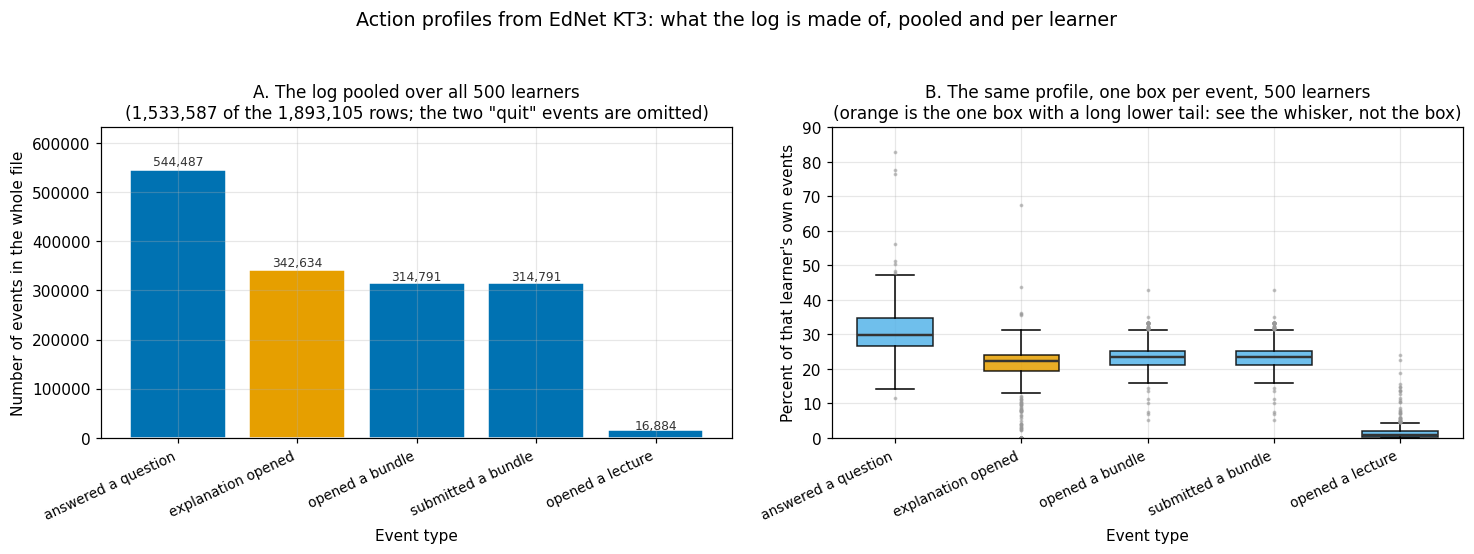

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
order = list(pooled.sort_values(ascending=False).index)
ax.bar(range(len(order)), [counts[e].sum() for e in order],
       color=[BLUE if e != 'enter_e' else ORANGE for e in order], edgecolor='white')
for i, e in enumerate(order):
    ax.text(i, counts[e].sum() * 1.02, format(int(counts[e].sum()), ','),
            ha='center', fontsize=8, color=BLACK)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([LABEL[e] for e in order], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Number of events in the whole file')
ax.set_xlabel('Event type')
ax.set_ylim(0, counts.sum().max() * 1.16)
ax.set_title('A. The log pooled over all 500 learners\n(1,533,587 of the 1,893,105 rows; the two "quit" events are omitted)')

ax = axes[1]
data = [share[e].values for e in order]
bp = ax.boxplot(data, vert=True, widths=0.6, patch_artist=True,
                medianprops=dict(color=BLACK, linewidth=1.6),
                flierprops=dict(marker='.', markersize=3, markerfacecolor=GREY,
                                markeredgecolor=GREY, alpha=0.5))
for patch, e in zip(bp['boxes'], order):
    patch.set_facecolor(ORANGE if e == 'enter_e' else SKY)
    patch.set_alpha(0.85)
ax.set_xticklabels([LABEL[e] for e in order], rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Percent of that learner's own events")
ax.set_xlabel('Event type')
ax.set_title('B. The same profile, one box per event, 500 learners\n'
             '(orange is the one box with a long lower tail: see the whisker, not the box)')
ax.set_ylim(0, 90)

fig.suptitle('Action profiles from EdNet KT3: what the log is made of, pooled and per learner',
             fontsize=12.5, y=1.04)
plt.tight_layout()
plt.show()

**Let's look at the output.** Panel A shows the log. Panel B is where the argument is.

1. `opened a bundle` and `submitted a bundle` have **identical** counts and identical boxes, because in this app one implies the other. A profile with both columns has one column of information and two columns of width. It may be worth looking back at any dashboard we have seen this semester and asking how many of its bars were structurally tied to each other.
2. Most of these boxes are narrow. The middle half of learners spend between 21.0 and 25.2 percent of their events opening bundles. That is what the data show. What are some plausible explanations before we call it a finding about consistent learners? Two are already available in what we know about the source. The instrument: the next bundle opens within 0.05 s of the explanation closing (Section 1.1), so the transition is not a separate human action and the ratio of opens to answers is close to fixed by design. The setting: this is test preparation, where the format is the point. Only after both of those does anything about a person become a candidate.
3. The orange box is the interesting one, and not because it is wide. Its middle half is narrow too, 19.4 to 24.1 percent, but its tenth percentile is **4.0** percent. The spread is all in a lower tail: for most learners the explanation share sits near a fifth of the log, and a minority sit far below it. What might separate the tail from the rest? It may be worth writing a hypothesis down here, since Section 5 returns to it with the evidence.
4. 42 of 500 learners have no recorded explanation open and 91 have no recorded lecture open. If those learners were dropped to make the averages tidier, which direction would every explanation statistic in this notebook move, and by roughly how much?

### Your turn 1

This cell puts one learner against the class. `FOCUS_LEARNER` can be set to any id in the file. The default works as it is, so the cell can also simply be run.

Learner ids look like `u1`, `u170`, `u2417`. The cell prints a few valid ones.

In [7]:
# TODO: change this to any learner id in the file, then rerun the cell.
FOCUS_LEARNER = 'u170'

valid = list(counts.index)
print('Some valid ids to try:', ', '.join(valid[:6]), '...  (%d learners in total)' % len(valid))
print()

if FOCUS_LEARNER not in counts.index:
    print('%r is not in this file. Pick one from the list above.' % FOCUS_LEARNER)
else:
    focus = share.loc[FOCUS_LEARNER]
    table = pd.DataFrame({
        'events': counts.loc[FOCUS_LEARNER],
        '%s (%%)' % FOCUS_LEARNER: focus.round(1),
        'class median (%)': share.median().round(1),
        'difference': (focus - share.median()).round(1),
    })
    table.index = [LABEL[e] for e in table.index]
    print('Profile of %s against the median of all 500 learners' % FOCUS_LEARNER)
    print(table.to_string())
    print()
    print('%s logged %s events in total. %.0f percent of the 500 learners logged fewer.'
          % (FOCUS_LEARNER, format(int(counts.loc[FOCUS_LEARNER].sum()), ','),
             100 * (counts.sum(axis=1) < counts.loc[FOCUS_LEARNER].sum()).mean()))
    print()
    print('A percentage and a count say different things. Please read both before describing')
    print('this learner.')

Some valid ids to try: u1, u10, u100, u101, u102, u103 ...  (500 learners in total)

Profile of u170 against the median of all 500 learners
                     events  u170 (%)  class median (%)  difference
opened a bundle          71      22.3              23.4        -1.0
answered a question      95      29.9              29.8         0.1
submitted a bundle       71      22.3              23.4        -1.0
explanation opened       59      18.6              22.3        -3.8
opened a lecture         22       6.9               0.8         6.1

u170 logged 318 events in total. 32 percent of the 500 learners logged fewer.

A percentage and a count say different things. Please read both before describing
this learner.


## 3. Cutting a stream into sessions

The file has no session column. It has a continuous stream of timestamps per learner, running over fifteen months. Almost every claim anyone wants to make about tutor use, such as "a typical study session" or "how much they get through in a sitting", needs sessions, so almost every analyst invents them.

The standard method is a **gap rule**: when the gap between two consecutive actions by the same person exceeds some threshold, call it a new session. The threshold is not in the data. Somebody picks it.

**Run the cell below** for the shape of the gaps, before any threshold is chosen.

Gaps between consecutive actions by the same learner: 1,892,605 gaps

  percentile   seconds        in human units
     1.0             0.03     0.0 s
    10.0             0.06     0.1 s
    25.0             0.98     1.0 s
    50.0             4.70     4.7 s
    75.0            18.54     18.5 s
    90.0            53.22     53.2 s
    95.0           116.94     1.9 min
    99.0          4522.62     75.4 min
    99.9        257710.26     71.6 hours

Share of all gaps longer than a candidate threshold:
     1 minutes : 170,683 gaps  (9.018% of all gaps)
     5 minutes :  48,078 gaps  (2.540% of all gaps)
    10 minutes :  32,920 gaps  (1.739% of all gaps)
    15 minutes :  28,352 gaps  (1.498% of all gaps)
    30 minutes :  23,310 gaps  (1.232% of all gaps)
    60 minutes :  19,926 gaps  (1.053% of all gaps)
   120 minutes :  17,035 gaps  (0.900% of all gaps)

Two things to check on the shape, because both matter for the rule:
   share of gaps under 0.2 s              : 0.177   (below hum

   tallest bin below 0.2 s, in the bins the figure uses: 0.0545 to 0.0694 s

   And in the range where a session rule has to live, counts per band:
          5 to    15 minutes :  19,726 gaps
         15 to    30 minutes :   5,042 gaps
         30 to    60 minutes :   3,384 gaps
         60 to   120 minutes :   2,891 gaps
        120 to   360 minutes :   3,929 gaps
        360 to   720 minutes :   2,736 gaps
        720 to  1440 minutes :   5,076 gaps
       1440 to  2880 minutes :   2,517 gaps
   It falls, then turns and rises again toward a day. That rise is consistent with a
   return the following day, and it is the closest thing to a natural boundary here.


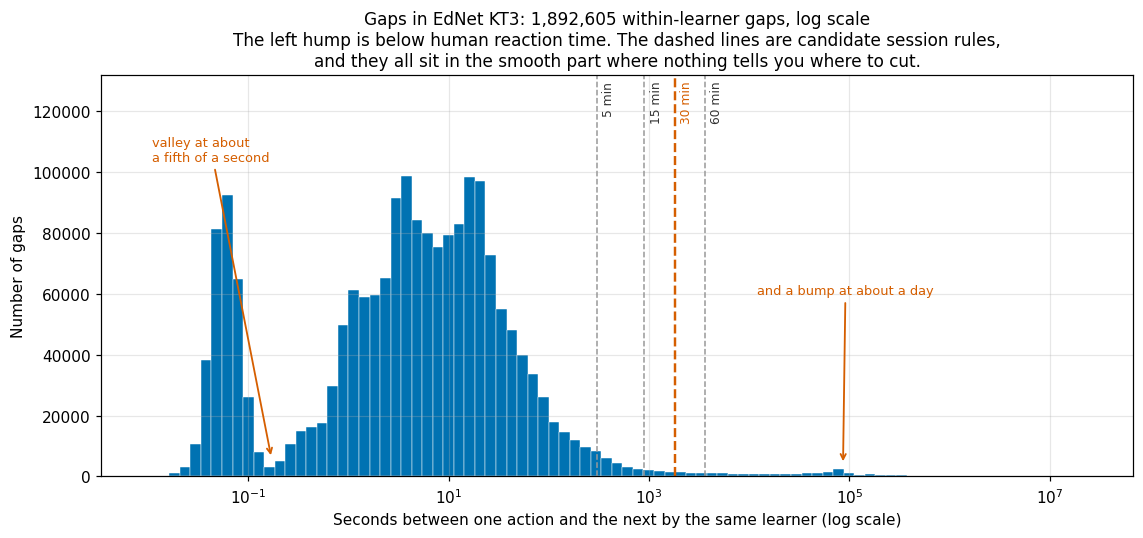

In [8]:
gaps = gap_s.dropna()
print('Gaps between consecutive actions by the same learner: %s gaps' % format(len(gaps), ','))
print()
pct = [1, 10, 25, 50, 75, 90, 95, 99, 99.9]
vals = np.percentile(gaps, pct)
print('  percentile   seconds        in human units')
for p, v in zip(pct, vals):
    if v < 90:
        human = '%.1f s' % v
    elif v < 5400:
        human = '%.1f min' % (v / 60)
    else:
        human = '%.1f hours' % (v / 3600)
    print('   %5.1f       %10.2f     %s' % (p, v, human))
print()
print('Share of all gaps longer than a candidate threshold:')
for m in [1, 5, 10, 15, 30, 60, 120]:
    print('   %3d minutes : %7s gaps  (%.3f%% of all gaps)'
          % (m, format(int((gaps > m * 60).sum()), ','), (gaps > m * 60).mean() * 100))
print()
print('Two things to check on the shape, because both matter for the rule:')
print('   share of gaps under 0.2 s              : %.3f   (below human reaction time)'
      % (gaps < 0.2).mean())
print('   share between 0.2 s and 1 s            : %.3f   (the dip)'
      % (((gaps >= 0.2) & (gaps < 1)).mean()))
print('   so there is a valley, and it is at a fifth of a second.')
hump_edges = np.logspace(np.log10(0.01), np.log10(gaps[gaps > 0].max()), 90)
hump_counts, _ = np.histogram(gaps[gaps > 0], bins=hump_edges)
below = np.where(hump_edges[1:] <= 0.2)[0]
tallest = below[np.argmax(hump_counts[below])]
print('   tallest bin below 0.2 s, in the bins the figure uses: %.4f to %.4f s'
      % (hump_edges[tallest], hump_edges[tallest + 1]))
print()
print('   And in the range where a session rule has to live, counts per band:')
for lo, hi in [(5, 15), (15, 30), (30, 60), (60, 120), (120, 360), (360, 720), (720, 1440),
               (1440, 2880)]:
    n = int(((gaps >= lo * 60) & (gaps < hi * 60)).sum())
    print('      %5d to %5d minutes : %7s gaps' % (lo, hi, format(n, ',')))
print('   It falls, then turns and rises again toward a day. That rise is consistent with a')
print('   return the following day, and it is the closest thing to a natural boundary here.')

fig, ax = plt.subplots(figsize=(10.5, 5.0))
positive = gaps[gaps > 0]
bins = np.logspace(np.log10(0.01), np.log10(positive.max()), 90)
ax.hist(positive, bins=bins, color=BLUE, edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_ylim(0, 132000)
ax.annotate('valley at about\na fifth of a second', xy=(0.17, 6000), xytext=(0.011, 112000),
            fontsize=8.5, color=VERMILLION, va='top',
            arrowprops=dict(arrowstyle='->', color=VERMILLION, linewidth=1.2))
ax.annotate('and a bump at about a day', xy=(86400, 4000),
            xytext=(12000, 60000), fontsize=8.5, color=VERMILLION,
            arrowprops=dict(arrowstyle='->', color=VERMILLION, linewidth=1.2))
for m, color in [(5, GREY), (15, GREY), (30, VERMILLION), (60, GREY)]:
    ax.axvline(m * 60, color=color, linestyle='--', linewidth=1.6 if m == 30 else 1.0)
    ax.text(m * 60 * 1.14, 130000, '%d min' % m, rotation=90,
            va='top', fontsize=8, color=VERMILLION if m == 30 else BLACK)
ax.set_xlabel('Seconds between one action and the next by the same learner (log scale)')
ax.set_ylabel('Number of gaps')
ax.set_title('Gaps in EdNet KT3: 1,892,605 within-learner gaps, log scale\n'
             'The left hump is below human reaction time. The dashed lines are candidate session rules,\n'
             'and they all sit in the smooth part where nothing tells you where to cut.')
plt.tight_layout()
plt.show()

**Let's look at the output.** The shape comes first, and anyone's threshold second.

1. The hump on the far left peaks at roughly a **sixteenth of a second**, and 17.7 percent of all gaps in this file are under a fifth of a second. What physical event produces a gap that short, and what does it do to any statistic that averages "time between actions" over all rows?
2. **There is a valley.** The clear separation in this distribution sits at about 0.2 seconds, and what it separates is the machine from the person rather than one study session from the next. Everywhere a session rule could plausibly go, from a few minutes to a couple of hours, the curve slides downward with no boundary in it. What does that mean for the claim that a session rule *discovers* sessions rather than *defines* them?
3. The one other feature worth naming is the rise after about six hours, peaking near a day. A plausible reading is people coming back tomorrow, and it is the only thing in this file that behaves like a natural unit. Nobody uses a 24 hour session rule. Why not, and what would be lost by using one?
4. Only 1.23 percent of gaps exceed 30 minutes, and 1.05 percent exceed an hour. Those two numbers are close together. Before Section 3.1, would a 5 minute rule and a 60 minute rule give roughly the same picture of a study session?
5. If we had to pick, what evidence outside this file would help? Is there a person we could ask?

*Connecting to the readings.* Winne (2022) asks, among his open questions about temporal attributes, whose model of a learning session overlays the data and the analytics: the analyst's or the learner's.

### 3.1 The session rule and a sensitivity check

We state the rule, apply it, and report the headline. Then, because a headline that depends on a choice is incomplete on its own, we move the choice and report how far the headline goes with it.

> **Session rule.** A new session begins when a learner's first ever action occurs, or when more than **30 minutes** pass since that learner's previous action.

Thirty minutes is a common choice and it is still a choice. **Run the two cells below.** The first computes the headline; the second moves the rule.

In [9]:
def sessionise(gap_minutes):
    # Return a session id per row under a stated gap rule, plus one row per session.
    starts_new = gap_s.isna() | (gap_s > gap_minutes * 60)
    sid = starts_new.cumsum()
    per_session = pd.DataFrame({
        'user_id': actions['user_id'].values,
        'session': sid.values,
        'timestamp': actions['timestamp'].values,
        'is_bundle_open': (actions['event'] == 'enter_b').values,
    }).groupby('session').agg(user_id=('user_id', 'first'),
                              n_actions=('timestamp', 'size'),
                              minutes=('timestamp', lambda s: (s.max() - s.min()) / 1000 / 60),
                              bundles=('is_bundle_open', 'sum'))
    return sid, per_session


GAP_MINUTES = 30
session_id, sessions = sessionise(GAP_MINUTES)

per_learner = sessions.groupby('user_id').agg(
    n_sessions=('n_actions', 'size'),
    median_actions=('n_actions', 'median'),
    median_minutes=('minutes', 'median'),
    median_bundles=('bundles', 'median'))

print('Under a %d minute rule:' % GAP_MINUTES)
print('   sessions in the whole file        : %s' % format(len(sessions), ','))
print('   learners with at least one session: %d' % per_learner.shape[0])
print()
print('Computed per learner first, then summarized across the 500 learners:')
print('   median sessions per learner       : %.0f' % per_learner['n_sessions'].median())
print('   median actions in a session       : %.2f' % per_learner['median_actions'].median())
print('   median minutes in a session       : %.2f' % per_learner['median_minutes'].median())
print('   HEADLINE, median bundles opened in a sitting: %.2f'
      % per_learner['median_bundles'].median())
print()
print('For contrast, the number computed over all sessions without regard to nesting,')
print('averaging over all %s sessions:' % format(len(sessions), ','))
print('   median bundles per session, pooled over sessions: %.2f' % sessions['bundles'].median())
print('   mean   bundles per session, pooled over sessions: %.2f' % sessions['bundles'].mean())
print('The pooled mean is pulled by the busiest learners, who contribute the most sessions.')

Under a 30 minute rule:
   sessions in the whole file        : 23,810
   learners with at least one session: 500

Computed per learner first, then summarized across the 500 learners:
   median sessions per learner       : 19
   median actions in a session       : 44.25
   median minutes in a session       : 16.02
   HEADLINE, median bundles opened in a sitting: 8.75

For contrast, the number computed over all sessions without regard to nesting,
averaging over all 23,810 sessions:
   median bundles per session, pooled over sessions: 8.00
   mean   bundles per session, pooled over sessions: 13.22
The pooled mean is pulled by the busiest learners, who contribute the most sessions.


SENSITIVITY OF THE HEADLINE TO THE SESSION RULE
                sessions in file  median sessions per learner  median actions per session  median minutes per session  HEADLINE bundles per sitting  % sessions of one action
gap rule (min)                                                                                                                                                               
5                          48578                         37.0                       22.00                        6.54                          5.00                       9.7
10                         33420                         27.0                       33.00                       10.59                          7.00                       4.3
15                         28852                         24.0                       38.00                       13.02                          7.75                       2.6
20                         26431                         22.0                     

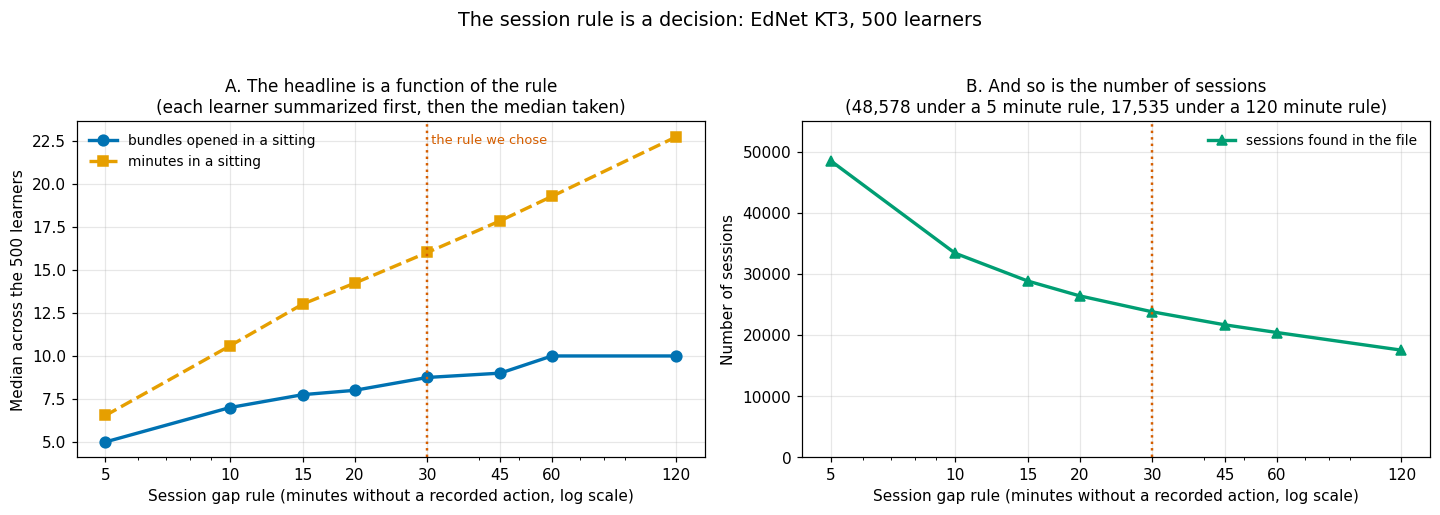

In [10]:
rows = []
for m in [5, 10, 15, 20, 30, 45, 60, 120]:
    _, s = sessionise(m)
    pl = s.groupby('user_id').agg(n=('n_actions', 'size'),
                                  a=('n_actions', 'median'),
                                  mi=('minutes', 'median'),
                                  b=('bundles', 'median'))
    rows.append({'gap rule (min)': m,
                 'sessions in file': len(s),
                 'median sessions per learner': pl['n'].median(),
                 'median actions per session': pl['a'].median(),
                 'median minutes per session': round(pl['mi'].median(), 2),
                 'HEADLINE bundles per sitting': pl['b'].median(),
                 '% sessions of one action': round((s['n_actions'] == 1).mean() * 100, 1)})
sensitivity = pd.DataFrame(rows).set_index('gap rule (min)')
print('SENSITIVITY OF THE HEADLINE TO THE SESSION RULE')
print(sensitivity.to_string())
print()
h = sensitivity['HEADLINE bundles per sitting']
print('The headline "a typical sitting is about %.1f bundles" moves from %.1f to %.1f'
      % (h.loc[30], h.min(), h.max()))
print('across defensible rules, a factor of %.1f. The minutes figure moves from %.1f to %.1f,'
      % (h.max() / h.min(), sensitivity['median minutes per session'].min(),
         sensitivity['median minutes per session'].max()))
print('a factor of %.1f. Nothing about the learners changed between those rows.'
      % (sensitivity['median minutes per session'].max()
         / sensitivity['median minutes per session'].min()))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.5))
x = sensitivity.index.values

ax = axes[0]
ax.plot(x, sensitivity['HEADLINE bundles per sitting'], marker='o', color=BLUE,
        linewidth=2.2, markersize=7, label='bundles opened in a sitting')
ax.plot(x, sensitivity['median minutes per session'], marker='s', color=ORANGE,
        linewidth=2.2, markersize=7, linestyle='--', label='minutes in a sitting')
ax.axvline(30, color=VERMILLION, linestyle=':', linewidth=1.6)
ax.text(30, ax.get_ylim()[1] * 0.97, ' the rule we chose', fontsize=8.5,
        color=VERMILLION, va='top')
ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x])
ax.set_xlabel('Session gap rule (minutes without a recorded action, log scale)')
ax.set_ylabel('Median across the 500 learners')
ax.set_title('A. The headline is a function of the rule\n(each learner summarized first, then the median taken)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(x, sensitivity['sessions in file'], marker='^', color=GREEN, linewidth=2.2,
        markersize=7, label='sessions found in the file')
ax.axvline(30, color=VERMILLION, linestyle=':', linewidth=1.6)
ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x])
ax.set_xlabel('Session gap rule (minutes without a recorded action, log scale)')
ax.set_ylabel('Number of sessions')
ax.set_ylim(0, 55000)
ax.set_title('B. And so is the number of sessions\n(48,578 under a 5 minute rule, 17,535 under a 120 minute rule)')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('The session rule is a decision: EdNet KT3, 500 learners',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Let's discuss.**

1. It may be instructive to write the headline twice: once as a vendor would print it, *"learners get through about 9 question screens in a typical sitting,"* and once in the version that contains the phrase "under a 30 minute rule". Which of the two turns up more often in the papers you have read?
2. Panel A shows the bundles figure doubling, from 5.0 to 10.0, and the minutes figure rising by a factor of 3.5, from 6.5 to 22.8, across the range. **Neither the learners nor the log changed.** What does that suggest about comparing a session statistic in one paper against a session statistic in another?
3. Under a 5 minute rule, 9.7 percent of sessions contain exactly one action. Under a 30 minute rule, 1.2 percent do. If an analysis excluded one-action sessions as noise, which rule would make the biggest difference to what was excluded, and would it be visible in the write-up?
4. **The instrument first.** This app runs on phones and in browsers, and phones are put down and picked up. What is it about phone use that makes a fixed gap rule a poor description of a study session, and what would the file need to contain to do better? Only then is it worth asking whether any of this is about how the person studies.

### Your turn 2

This cell moves the rule and shows the headline moving with it. It ships with **10 minutes**, deliberately different from the notebook's 30.

In [11]:
# TODO: change this and rerun. Try 5, then 30, then 120.
MY_GAP_MINUTES = 10

_, my_sessions = sessionise(MY_GAP_MINUTES)
mine = my_sessions.groupby('user_id').agg(n=('n_actions', 'size'),
                                          b=('bundles', 'median'),
                                          mi=('minutes', 'median'))
print('Your rule: a new session after %d minutes without a recorded action.' % MY_GAP_MINUTES)
print("The notebook's rule: %d minutes." % GAP_MINUTES)
print()
print('                                     yours     notebook    change')
print('sessions in the file             %9s %12s %9s'
      % (format(len(my_sessions), ','), format(len(sessions), ','),
         format(len(my_sessions) - len(sessions), '+,')))
print('median bundles in a sitting      %9.2f %12.2f %+9.2f'
      % (mine['b'].median(), per_learner['median_bundles'].median(),
         mine['b'].median() - per_learner['median_bundles'].median()))
print('median minutes in a sitting      %9.2f %12.2f %+9.2f'
      % (mine['mi'].median(), per_learner['median_minutes'].median(),
         mine['mi'].median() - per_learner['median_minutes'].median()))
print()
print('Please say, in one sentence you would defend in a dissertation defense, which of these')
print('two numbers is a fact about these 500 learners\' recorded activity.')

Your rule: a new session after 10 minutes without a recorded action.
The notebook's rule: 30 minutes.

                                     yours     notebook    change
sessions in the file                33,420       23,810    +9,610
median bundles in a sitting           7.00         8.75     -1.75
median minutes in a sitting          10.59        16.02     -5.42

Please say, in one sentence you would defend in a dissertation defense, which of these
two numbers is a fact about these 500 learners' recorded activity.


## 4. Order: what follows what

Profiles count events. Regulation, in Winne's account, is about **order**: reviewing feedback you never earned is not evaluation, and planning after you finish is not planning. So the order is worth looking at directly.

The simplest order statistic is the **bigram**: every neighboring pair of events, with the earlier one in the rows and the later one in the columns, each row divided by its own total. The table below reads: given that a learner has just done the row event, what did they do next, as a percentage.

Pairs are taken **within a learner only**, so we never count the last action of one person followed by the first action of the next.

**Run the cell below.**

Bigram counts, 1,892,605 within-learner pairs:
event      enter_b  respond_q  submit_b  enter_e  quit_e  enter_l  quit_l
event                                                                    
enter_b          0     300162     14629        0       0        0       0
respond_q        0     242889    300162        0    1434        0       2
submit_b     16400          0         0   296962       0     1241       0
enter_e          0       1434         0        0  341200        0       0
quit_e      290966          0         0    44009       0     7374       0
enter_l          0          2         0        0       0        0   16882
quit_l        6944          0         0     1652       0     8261       0

Row percentages: given the row event, what happened next (%)
event      enter_b  respond_q  submit_b  enter_e  quit_e  enter_l  quit_l
event                                                                    
enter_b        0.0       95.4       4.6      0.0     0.0      0.0     0.0
res

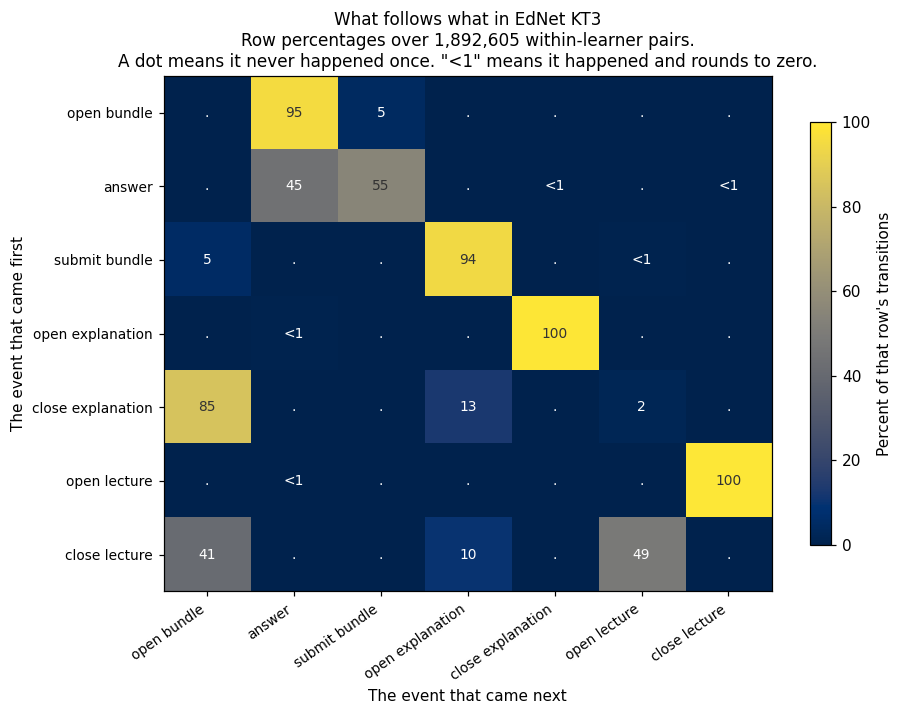

In [12]:
STATE_ORDER = ['enter_b', 'respond_q', 'submit_b', 'enter_e', 'quit_e', 'enter_l', 'quit_l']
PRETTY = {'enter_b': 'open bundle', 'respond_q': 'answer', 'submit_b': 'submit bundle',
          'enter_e': 'open explanation', 'quit_e': 'close explanation',
          'enter_l': 'open lecture', 'quit_l': 'close lecture'}

next_event = actions['event'].shift(-1)
same_learner = actions['user_id'] == actions['user_id'].shift(-1)
pairs = pd.crosstab(actions['event'][same_learner], next_event[same_learner])
pairs = pairs.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)
transition = pairs.div(pairs.sum(axis=1), axis=0) * 100

print('Bigram counts, %s within-learner pairs:' % format(int(pairs.values.sum()), ','))
print(pairs.to_string())
print()
print('Row percentages: given the row event, what happened next (%)')
print(transition.round(1).to_string())

fig, ax = plt.subplots(figsize=(8.6, 6.6))
im = ax.imshow(transition.values, cmap='cividis', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(STATE_ORDER)))
ax.set_xticklabels([PRETTY[s] for s in STATE_ORDER], rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(STATE_ORDER)))
ax.set_yticklabels([PRETTY[s] for s in STATE_ORDER], fontsize=9)
for i in range(len(STATE_ORDER)):
    for j in range(len(STATE_ORDER)):
        v = transition.values[i, j]
        n = pairs.values[i, j]
        if n == 0:
            label = '.'          # never once happened
        elif v < 0.5:
            label = '<1'         # happened, but rounds to zero
        else:
            label = '%.0f' % v
        ax.text(j, i, label, ha='center', va='center', fontsize=9,
                color='white' if v < 55 else BLACK)
ax.set_xlabel('The event that came next')
ax.set_ylabel('The event that came first')
ax.set_title('What follows what in EdNet KT3\n'
             'Row percentages over 1,892,605 within-learner pairs.\n'
             'A dot means it never happened once. "<1" means it happened and rounds to zero.')
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label('Percent of that row\'s transitions')
ax.grid(False)
plt.tight_layout()
plt.show()

**Let's look at the output.** Most of this grid is empty, and the empty parts are the interesting parts.

1. There are **19 of 49** cells that are not a dot, because the app allows only certain orders. **A dot here is a fact about the software rather than about people.** There are also five cells marked `<1`. They happened, 1,434 times in two of them, and a grid rounded to whole percentages would have shown a zero.
2. `submit bundle` is followed by `open explanation` **94.4 percent** of the time. That is what the data show. Two readings are available: these are curious learners who always check the explanation, or they never chose anything at all. What in the file could distinguish them?
3. `answer` is followed by `answer` 44.6 percent of the time. Some of that is multi-question bundles and some of it is a learner changing the selected option before submitting, which the documentation says is permitted and which the Section 1.2 audit counts. The bigram cannot distinguish those. What would the matrix need in order to?
4. `close explanation` is followed by `open explanation` **12.9 percent** of the time. Section 7 comes back to this cell with a breakdown that changes how it reads.

## 5. The first logging artifact

Here is a study design that would look reasonable.

> *Explanation viewing as a self-regulation indicator.* We operationalize help seeking as the number of explanation screens a learner opened. Learners in the top quartile of explanation use are compared with the bottom quartile on ...

Section 4 already suggested something is off with it. If an explanation opens **94.4 percent** of the times a bundle is submitted, the question is not why learners open explanations so often. The question is whether they open them at all.

**Timing is what separates the two readings.** The documentation says explanations are given to the learner after each bundle (riiid/ednet README); the timing below is the check. **Run the cell below.** It measures the seconds between submitting a bundle and the explanation appearing.

Explanation screens that appear immediately after a submit: 296,962
   of which the explanation is for the bundle just submitted: 99.35%

Seconds from submitting the bundle to the explanation appearing:
   overall     median 0.077 s   share under 0.2 s 60.7%   share under 2 s 90.9%
   mobile   n= 182,748  median 0.057 s   share under 0.2 s  98.6%  (180,232 of 182,748 screens)
   web      n= 114,214  median 1.317 s   share under 0.2 s   0.0%  (18 of 114,214 screens)

Human simple reaction time to a visual signal is commonly reported as roughly 0.2 to
0.25 seconds, and that is before deciding anything. A median of 0.057 s on mobile is below
human reaction time.


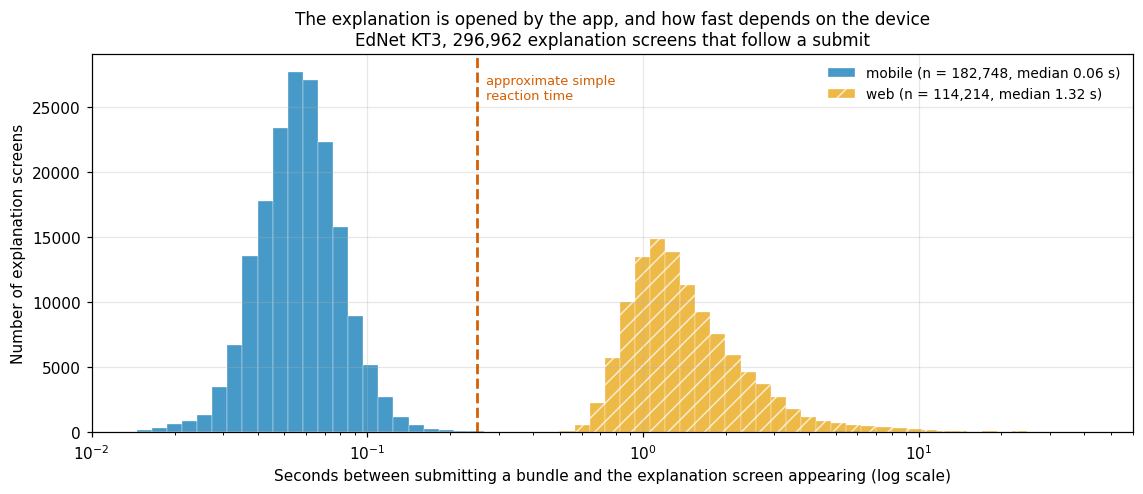

In [13]:
prev_event = actions['event'].shift()
prev_num = actions['item_num'].shift()
prev_time = actions['timestamp'].shift()
same_prev = actions['user_id'] == actions['user_id'].shift()

opened_after_submit = ((actions['event'] == 'enter_e') & same_prev
                       & (prev_event == 'submit_b') & (prev_num == actions['item_num']))
latency = ((actions['timestamp'] - prev_time) / 1000.0)[
    (actions['event'] == 'enter_e') & same_prev & (prev_event == 'submit_b')]
latency_platform = actions['platform'][latency.index]

print('Explanation screens that appear immediately after a submit: %s'
      % format(int(latency.shape[0]), ','))
print('   of which the explanation is for the bundle just submitted: %.2f%%'
      % ((actions['item_num'][latency.index] == prev_num[latency.index]).mean() * 100))
print()
print('Seconds from submitting the bundle to the explanation appearing:')
print('   overall     median %.3f s   share under 0.2 s %.1f%%   share under 2 s %.1f%%'
      % (latency.median(), (latency < 0.2).mean() * 100, (latency < 2).mean() * 100))
for p in ['mobile', 'web']:
    lp = latency[latency_platform == p]
    print('   %-8s n=%8s  median %.3f s   share under 0.2 s %5.1f%%  (%s of %s screens)'
          % (p, format(len(lp), ','), lp.median(), (lp < 0.2).mean() * 100,
             format(int((lp < 0.2).sum()), ','), format(len(lp), ',')))
print()
print('Human simple reaction time to a visual signal is commonly reported as roughly 0.2 to')
print('0.25 seconds, and that is before deciding anything. A median of %.3f s on mobile is below'
      % latency[latency_platform == 'mobile'].median())
print('human reaction time.')

fig, ax = plt.subplots(figsize=(10.5, 4.6))
bins = np.logspace(np.log10(0.01), np.log10(60), 70)
for p, color, hatch in [('mobile', BLUE, None), ('web', ORANGE, '//')]:
    lp = latency[(latency_platform == p) & (latency > 0)]
    ax.hist(lp, bins=bins, color=color, alpha=0.72, hatch=hatch, edgecolor='white',
            linewidth=0.3, label='%s (n = %s, median %.2f s)' % (p, format(len(lp), ','), lp.median()))
ax.axvline(0.25, color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(0.26, ax.get_ylim()[1] * 0.88, ' approximate simple\n reaction time',
        fontsize=8.5, color=VERMILLION)
ax.set_xscale('log')
ax.set_xlim(0.01, 60)
ax.set_xlabel('Seconds between submitting a bundle and the explanation screen appearing (log scale)')
ax.set_ylabel('Number of explanation screens')
ax.set_title('The explanation is opened by the app, and how fast depends on the device\n'
             'EdNet KT3, 296,962 explanation screens that follow a submit')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Let's discuss.**

1. On **mobile**, 98.6 percent of these explanation screens appear within a fifth of a second of the submit. Human simple reaction time to a visual signal is commonly reported as roughly 0.2 to 0.25 seconds, and that is before deciding anything. How would the imaginary abstract at the top of this section have to be rewritten so that it says what "number of explanations opened" is measuring?
2. On **web**, the median is 1.32 seconds and the share under 0.2 seconds rounds to zero: 18 screens out of 114,214, about one in six thousand. It is the same product and the same event type on a different client. Suppose that latency had been used as a measure of how quickly a learner turns to help. What would the published finding have been about?
3. What would you call it in your own words: a variable that looks like a decision and is a **default**? An example from a learning platform you have used or built is worth having ready.
4. What would we have to know that is not in this file to be sure which explanations were chosen? It is worth writing the question down, and noticing that it is a question for a product manager rather than for a statistician.

Three things to keep separate:

| | |
|---|---|
| **What the data directly show** | 296,962 explanation screens follow a submit; 99.35 percent of them are for the bundle just submitted; the median gap is 0.077 s overall, 0.057 s on mobile and 1.317 s on web |
| **A plausible interpretation** | On mobile the explanation screen is part of the submit rather than a separate decision, consistent with the documentation, which says explanations are given after each bundle, so a count of explanation opens is closer to a count of submits than to a count of choices |
| **What this file cannot establish** | What the interface actually presented, whether any individual open was deliberate, or why the two clients differ. The log records events, not screens |

Across the 500 learners:
   explanation screens opened vs bundles submitted
      Pearson  r = 0.9825   (on raw counts, which are heavily right skewed)
      Spearman r = 0.9953   (on ranks, which is the one to trust here)
   explanations per bundle submitted, per learner:
      median 1.008, 10th percentile 0.125, 90th percentile 1.191

A Spearman of 0.995 means that ranking learners by "explanation use" reproduces the
ranking by "how much they used the app" almost exactly. It is a volume measure.

And the 42 learners with no recorded explanation open? Their volume comes first:
   their total events: smallest 7, median 21, largest 40
   across all 500 learners the median is 1,051 events and the largest is 49,556.
   learners with 100 or more events who never opened an explanation: 0

Among the 409 learners with 100 or more events, the explanation share is pinned:
   5th percentile 18.3%, median 22.9%, 90th percentile 26.0%
   and only 3 of them sit below 10%.
So the long lower tail in

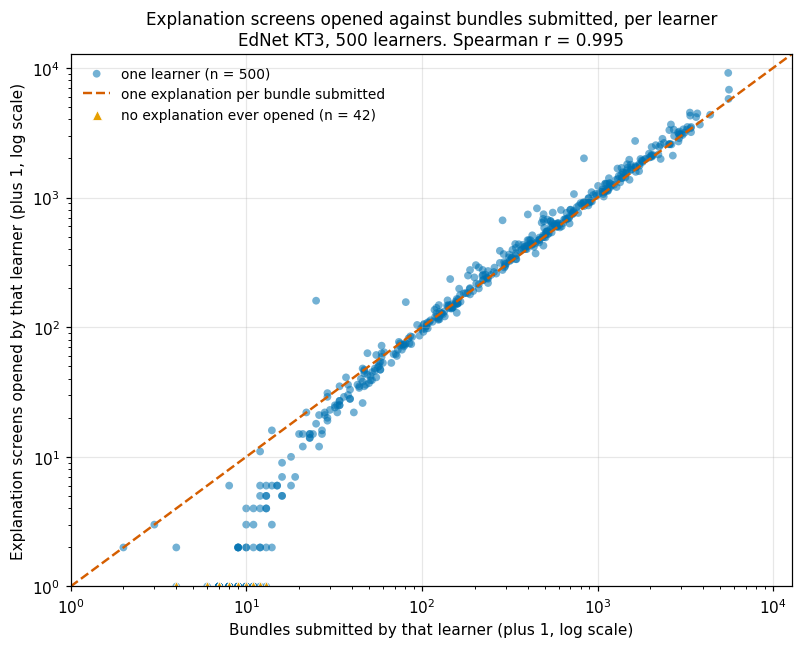

In [14]:
opens = counts['enter_e']
submits = counts['submit_b']
pearson = np.corrcoef(opens, submits)[0, 1]
ranks = pd.DataFrame({'o': opens, 's': submits}).rank()
spearman = np.corrcoef(ranks['o'], ranks['s'])[0, 1]
ratio = (opens / submits.replace(0, np.nan)).dropna()

print('Across the 500 learners:')
print('   explanation screens opened vs bundles submitted')
print('      Pearson  r = %.4f   (on raw counts, which are heavily right skewed)' % pearson)
print('      Spearman r = %.4f   (on ranks, which is the one to trust here)' % spearman)
print('   explanations per bundle submitted, per learner:')
print('      median %.3f, 10th percentile %.3f, 90th percentile %.3f'
      % (ratio.median(), ratio.quantile(.10), ratio.quantile(.90)))
print()
print('A Spearman of %.3f means that ranking learners by "explanation use" reproduces the' % spearman)
print('ranking by "how much they used the app" almost exactly. It is a volume measure.')
print()

total_events = counts.sum(axis=1)
never = counts.index[counts['enter_e'] == 0]
print('And the %d learners with no recorded explanation open? Their volume comes first:'
      % len(never))
print('   their total events: smallest %d, median %d, largest %d'
      % (total_events[never].min(), total_events[never].median(), total_events[never].max()))
print('   across all 500 learners the median is %s events and the largest is %s.'
      % (format(int(total_events.median()), ','), format(int(total_events.max()), ',')))
print('   learners with 100 or more events who never opened an explanation: %d'
      % int(((counts['enter_e'] == 0) & (total_events >= 100)).sum()))
print()
regulars = share['enter_e'][total_events >= 100]
print('Among the %d learners with 100 or more events, the explanation share is pinned:' % len(regulars))
print('   5th percentile %.1f%%, median %.1f%%, 90th percentile %.1f%%'
      % (regulars.quantile(.05), regulars.median(), regulars.quantile(.90)))
print('   and only %d of them sit below 10%%.' % int((regulars < 10).sum()))
print('So the long lower tail in Section 2 was not a kind of learner. It was people with')
print('almost no log at all. Once a person uses the app, the app opens explanations for them.')

fig, ax = plt.subplots(figsize=(7.4, 6.0))
ax.scatter(submits + 1, opens + 1, s=26, color=BLUE, alpha=0.55, edgecolor='none',
           label='one learner (n = 500)')
lim = [1, max(submits.max(), opens.max()) * 1.4]
ax.plot(lim, lim, color=VERMILLION, linestyle='--', linewidth=1.6,
        label='one explanation per bundle submitted')
zero = opens == 0
ax.scatter(submits[zero] + 1, opens[zero] + 1, s=42, color=ORANGE, marker='^',
           edgecolor='white', linewidth=0.5, label='no explanation ever opened (n = %d)' % int(zero.sum()))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Bundles submitted by that learner (plus 1, log scale)')
ax.set_ylabel('Explanation screens opened by that learner (plus 1, log scale)')
ax.set_title('Explanation screens opened against bundles submitted, per learner\n'
             'EdNet KT3, 500 learners. Spearman r = %.3f' % spearman)
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

**Let's look at the output.**

1. The points sit on the diagonal. One reading is that the app puts them there; a measure correlating at 0.995 with total activity is hard to distinguish from total activity. Is there another learning-analytics measure we have met this semester that might have this property, and how would you check?
2. **This is where the Section 2 hypothesis gets its evidence.** The long lower tail in the orange box invited a guess about a kind of learner. The printout shows that all 42 learners with no explanation event have between 7 and 40 logged events in total, against a class median of 1,051, and that **no** learner with 100 or more events is among them. Among the 409 regular users the explanation share sits between 18.3 and 26.0 percent from the 5th to the 90th percentile. The tail is people with almost no log.
3. That is worth naming as a general failure mode. A measure that behaves differently for people with little data will produce a group that is really a sample-size artifact, and it will look like a finding. Where else this semester has a group been defined, in effect, by how much of it there was to measure?
4. Suppose a dashboard ranked these 500 people on "explanation use" and showed the bottom decile to a tutor. What would the tutor be likely to say out loud, and what does the data support?
5. So what might a defensible measure of engaging with an explanation look like, given only this file? The timing is one candidate.

*Connecting to the readings.* Zhang, Borchers and Barany (2024) compare self-regulated learning across three intelligent tutoring systems that differ in how much they scaffold, and report that students engaged in more SRL transitions in the less scaffolded, open-ended platforms, while highly scaffolded environments made it easier to enact problem-solving operations without prior planning. Santa sits at the heavily scaffolded end: it delivers the explanation rather than waiting to be asked. Their finding is a reason to expect that what we can measure here about regulation is partly a property of the platform.

## 6. The second logging artifact

The most common study on a tutor log is: **do learners who use the help do better?** It compares accuracy on items where help was consumed against accuracy on items where it was not.

This extract has **no answer key**, so that study cannot be run here. That turns out to be useful, because it makes room to ask what it would have been measuring.

The reasoning has three steps:

1. How often does a learner answer the same question more than once?
2. Of those repeats, how many come after the learner has already been shown that bundle's explanation?
3. Do those post-explanation answers look like knowledge, or like reproduction?

**Run the cell below** for the first two steps.

In [15]:
# Episode-level bundle identity, restricted to rows inside their own learner's episode.
inside = actions[in_own_episode & (actions['episode'] > 0)]
bundle_of_episode = actions.loc[actions['event'] == 'enter_b'].set_index('episode')['item_num']

answers = inside[inside['event'] == 'respond_q'].copy()
answers['bundle'] = answers['episode'].map(bundle_of_episode)
# An answer is the last response before the submit, as the documentation defines it. Earlier
# responses in the same attempt are changed selections, audited in Section 1.2, item 7a.
answers = answers.groupby(['episode', 'item_num']).tail(1)
answers['answer_number_for_this_learner'] = answers.groupby(['user_id', 'item_num']).cumcount()

# The first time this learner opened the explanation for this bundle.
expl_opens = actions.loc[actions['event'] == 'enter_e', ['user_id', 'item_num', 'timestamp']]
first_expl = expl_opens.groupby(['user_id', 'item_num'])['timestamp'].min()
answers['explanation_first_seen'] = pd.MultiIndex.from_arrays(
    [answers['user_id'], answers['bundle']]).map(first_expl)
answers['already_shown'] = (answers['explanation_first_seen'].notna()
                            & (answers['explanation_first_seen'] < answers['timestamp']))

pairs_lq = answers.groupby(['user_id', 'item_num']).size()
print('STEP 1. Repeats.')
print('   An answer is the last response before the submit, as the documentation defines it, so')
print('   the changed selections counted in Section 1.2 item 7a are not answers here.')
print('   answers in the file                       : %s' % format(len(answers), ','))
print('   distinct learner-and-question pairs       : %s' % format(len(pairs_lq), ','))
print('   pairs answered more than once             : %s  (%.1f%% of pairs)'
      % (format(int((pairs_lq > 1).sum()), ','), (pairs_lq > 1).mean() * 100))
print('   answers that are a second attempt at that question: %s  (%.1f%% of all answers)'
      % (format(int(len(answers) - len(pairs_lq)), ','),
         100 * (len(answers) - len(pairs_lq)) / len(answers)))
print()
print('STEP 2. Was the explanation already shown?')
print('   "already shown" is matched by bundle, and Section 1.2 item 7b counts the questions that')
print('   appear under more than one bundle number, so this count is a lower bound.')
tab = pd.crosstab(answers['answer_number_for_this_learner'] > 0, answers['already_shown'],
                  margins=True)
tab.index = ['first time this learner answered it', 'a second attempt', 'All']
tab.columns = ['explanation not yet shown', 'explanation already shown', 'All']
print(tab.to_string())
print()
print('   share of FIRST answers preceded by that explanation : %.2f%%'
      % (answers.loc[answers['answer_number_for_this_learner'] == 0, 'already_shown'].mean() * 100))
print('   share of SECOND attempts preceded by that explanation: %.2f%%'
      % (answers.loc[answers['answer_number_for_this_learner'] > 0, 'already_shown'].mean() * 100))
print('   share of ALL answers preceded by that explanation   : %.2f%%'
      % (answers['already_shown'].mean() * 100))

STEP 1. Repeats.
   An answer is the last response before the submit, as the documentation defines it, so
   the changed selections counted in Section 1.2 item 7a are not answers here.
   answers in the file                       : 384,564
   distinct learner-and-question pairs       : 321,529
   pairs answered more than once             : 47,598  (14.8% of pairs)
   answers that are a second attempt at that question: 63,035  (16.4% of all answers)

STEP 2. Was the explanation already shown?
   "already shown" is matched by bundle, and Section 1.2 item 7b counts the questions that
   appear under more than one bundle number, so this count is a lower bound.
                                     explanation not yet shown  explanation already shown     All
first time this learner answered it                     317232                       4297  321529
a second attempt                                          3447                      59588   63035
All                                      

**Let's look at the output.** 16.6 percent of the answers in this file were recorded after that bundle's explanation had already been opened. Among second attempts it is 94.5 percent.

Now suppose the answer key existed. Accuracy is computed on answers where help had been consumed, compared with accuracy where it had not, and the help group is more accurate. The write-up says that explanation viewing supports learning.

**One reading of that result is that it measures the logging convention rather than the learning.** That reading rests on an assumption about the product: that a Santa explanation screen presents the solution to the item. The assumption is plausible and it is not something this extract can confirm, because the extract holds no screen content, only the event that a screen opened. If the assumption holds, an answer given after the explanation is an answer given with the solution having been on the screen at some earlier time, within the previous 24 hours for 17,225 of the 48,440 post-explanation answers Step 3 uses, and the comparison is not between a learner who used help and a learner who did not.

The direction generalizes. Wherever a tutor logs help **before** the outcome it scores, the outcome after help is partly determined by the logging rather than by the learner. In a system where the hint contains the answer, the recorded outcome after a hint would depend on whether the system credits the post-hint attempt. Either way part of the number is about the system.

Accuracy cannot be checked here. Something close to it can be, and it needs no answer key: if post-explanation answers are reproduction, the chosen options should pile up on one option. **Run the cell below.**

STEP 3. Concentration of the chosen option.
   questions with at least 10 independent answers in BOTH conditions: 1,241
   rows in each condition after keeping one answer per learner per question, all questions:
      317,244 at first exposure, 48,440 after the explanation screen opened

   share of answers on the single most chosen option, per question:
      first exposure               median 0.587   mean 0.600
      after the explanation shown  median 0.750   mean 0.743
      median difference            +0.142
      questions where it rises     1,040 of 1,241 (83.8%)


      bootstrap 95% interval on the median difference, resampling QUESTIONS:
         [+0.133, +0.154]
      A caveat to carry: the same 500 learners appear across many questions, so
      questions are not fully independent either and this interval is optimistic.

   Answers per question, which are not the same in the two conditions:
      first exposure               median 67
      after the explanation shown  median 14



   SAME COMPARISON WITH THE SAMPLE SIZE HELD FIXED
      first-exposure answers thinned to match each question's post-explanation count
      median difference                +0.132   (was +0.142 unmatched)
      spread across 25 thinnings       0.0071
      The matched difference is 7% below the unmatched one; that part of the raw gap
      is consistent with the sample-size bias of the statistic.
      The difference survives the correction and is smaller than the unmatched figure.
      Please report the matched number. The bootstrap interval above is an interval on
      the UNMATCHED statistic and does not cover this one.

   And when the answer comes within 24 hours of the explanation (17,225 answers, 191 questions):
      first exposure median 0.511   ->   after the explanation median 0.833
      but the two sides differ in size again: 111 answers per question against 13,
      and thinning the first-exposure side to match lifts its median from 0.511 to 0.544.
      The 0.83 is 

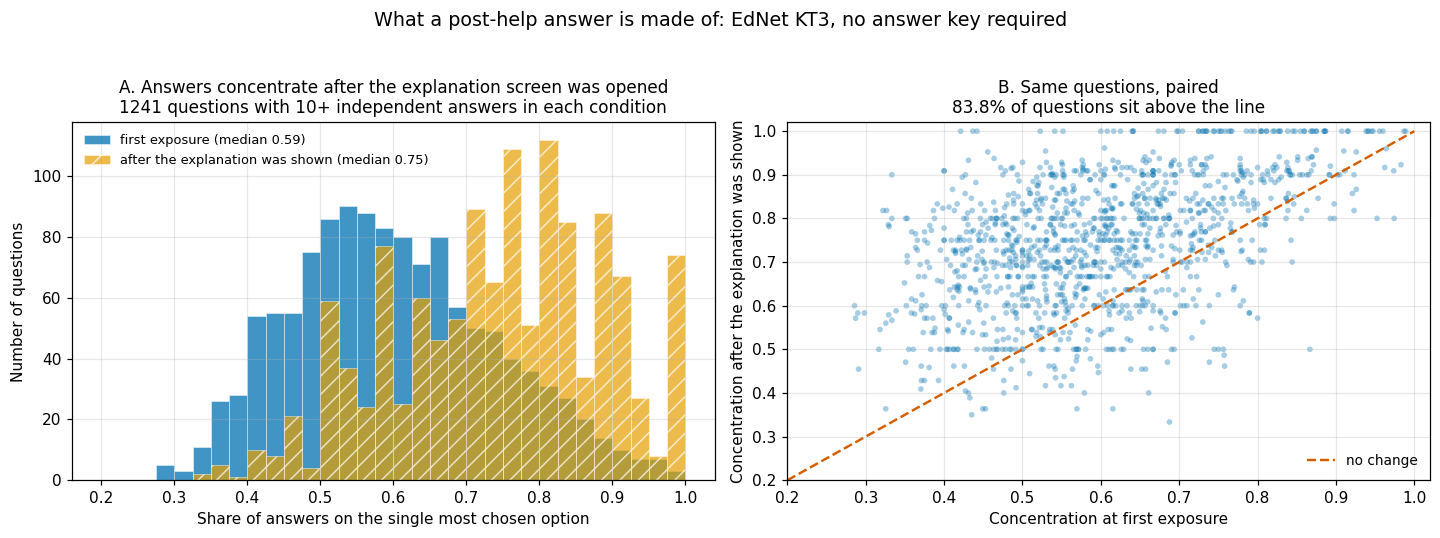

In [16]:
# STEP 3. If a post-explanation answer is reproduction, the chosen options should pile up
# on one option. Concentration needs no answer key.
MIN_ANSWERS_PER_QUESTION = 10

def modal_share(frame):
    # Per question: the share of answers falling on the single most chosen option.
    g = frame.groupby(['item_num', 'user_answer'], observed=True).size().rename('n').reset_index()
    total = g.groupby('item_num')['n'].sum()
    top = g.groupby('item_num')['n'].max()
    keep = total[total >= MIN_ANSWERS_PER_QUESTION].index
    return top[keep] / total[keep]

# One answer per learner per question in each condition, so the rows inside a question are
# 10+ different people and not one person answering ten times.
first_exposure = (answers[~answers['already_shown']]
                  .sort_values('timestamp').drop_duplicates(['user_id', 'item_num']))
after_shown = (answers[answers['already_shown']]
               .sort_values('timestamp').drop_duplicates(['user_id', 'item_num']))

conc_first = modal_share(first_exposure)
conc_after = modal_share(after_shown)
q = conc_first.index.intersection(conc_after.index)
delta = conc_after[q] - conc_first[q]

print('STEP 3. Concentration of the chosen option.')
print('   questions with at least %d independent answers in BOTH conditions: %s'
      % (MIN_ANSWERS_PER_QUESTION, format(len(q), ',')))
print('   rows in each condition after keeping one answer per learner per question, all questions:')
print('      %s at first exposure, %s after the explanation screen opened'
      % (format(len(first_exposure), ','), format(len(after_shown), ',')))
print()
print('   share of answers on the single most chosen option, per question:')
print('      first exposure               median %.3f   mean %.3f'
      % (conc_first[q].median(), conc_first[q].mean()))
print('      after the explanation shown  median %.3f   mean %.3f'
      % (conc_after[q].median(), conc_after[q].mean()))
print('      median difference            %+.3f' % delta.median())
print('      questions where it rises     %s of %s (%.1f%%)'
      % (format(int((delta > 0).sum()), ','), format(len(delta), ','), (delta > 0).mean() * 100))

rng = np.random.default_rng(8100)
boot = np.array([np.median(delta.values[rng.integers(0, len(delta), len(delta))])
                 for _ in range(4000)])
print('      bootstrap 95% interval on the median difference, resampling QUESTIONS:')
print('         [%+.3f, %+.3f]' % (np.percentile(boot, 2.5), np.percentile(boot, 97.5)))
print('      A caveat to carry: the same 500 learners appear across many questions, so')
print('      questions are not fully independent either and this interval is optimistic.')
print()

# ---------------------------------------------------------------------------
# The statistic itself is biased, and the two conditions are biased by different
# amounts. "Share on the most chosen option" rises when a question has fewer
# answers, purely by sampling: with ten answers the top option can look dominant
# by luck, with two hundred it cannot. And the two conditions here do NOT have
# the same number of answers per question.
#
# So before believing the +0.142, hold the sample size fixed: for each question,
# draw from its first-exposure answers exactly as many as it has post-explanation
# answers, and recompute. This is the same sample-size artifact Section 5 caught
# in the explanation share, arriving in a different disguise.
# ---------------------------------------------------------------------------
n_first = first_exposure.groupby('item_num').size()
n_after = after_shown.groupby('item_num').size()
print('   Answers per question, which are not the same in the two conditions:')
print('      first exposure               median %.0f' % n_first[q].median())
print('      after the explanation shown  median %.0f' % n_after[q].median())
print()

pool = {k: v['user_answer'].to_numpy()
        for k, v in first_exposure[first_exposure['item_num'].isin(q)].groupby('item_num')}
rng2 = np.random.default_rng(8100)
matched = []
for _ in range(25):
    diffs = []
    for k in q:
        arr = pool[k]
        n = min(int(n_after[k]), len(arr))
        draw = rng2.choice(arr, n, replace=False)
        _, c = np.unique(draw, return_counts=True)
        diffs.append(conc_after[k] - c.max() / n)
    matched.append(np.median(diffs))
matched = np.array(matched)
print('   SAME COMPARISON WITH THE SAMPLE SIZE HELD FIXED')
print('      first-exposure answers thinned to match each question\'s post-explanation count')
print('      median difference                %+.3f   (was %+.3f unmatched)'
      % (matched.mean(), delta.median()))
print('      spread across 25 thinnings       %.4f' % matched.std())
print('      The matched difference is %.0f%% below the unmatched one; that part of the raw gap'
      % (100 * (1 - matched.mean() / delta.median())))
print('      is consistent with the sample-size bias of the statistic.')
print('      The difference survives the correction and is smaller than the unmatched figure.')
print('      Please report the matched number. The bootstrap interval above is an interval on')
print('      the UNMATCHED statistic and does not cover this one.')
print()
within_a_day = after_shown[(after_shown['timestamp']
                            - after_shown['explanation_first_seen']) <= 86400 * 1000]
conc_fresh = modal_share(within_a_day)
q2 = conc_first.index.intersection(conc_fresh.index)
n_fresh = within_a_day.groupby('item_num').size()
print('   And when the answer comes within 24 hours of the explanation (%s answers, %s questions):'
      % (format(len(within_a_day), ','), format(len(q2), ',')))
print('      first exposure median %.3f   ->   after the explanation median %.3f'
      % (conc_first[q2].median(), conc_fresh[q2].median()))
pool2 = {k: v['user_answer'].to_numpy()
         for k, v in first_exposure[first_exposure['item_num'].isin(q2)].groupby('item_num')}
rng3 = np.random.default_rng(8100)
m2 = []
for _ in range(25):
    vals = []
    for k in q2:
        arr = pool2[k]
        n = min(int(n_fresh[k]), len(arr))
        draw = rng3.choice(arr, n, replace=False)
        _, c = np.unique(draw, return_counts=True)
        vals.append(c.max() / n)
    m2.append(np.median(vals))
print('      but the two sides differ in size again: %.0f answers per question against %.0f,'
      % (n_first[q2].median(), n_fresh[q2].median()))
print('      and thinning the first-exposure side to match lifts its median from %.3f to %.3f.'
      % (conc_first[q2].median(), float(np.mean(m2))))
print('      The 0.83 is still well above that, and the gap is smaller than the unmatched pair.')

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))

ax = axes[0]
bins = np.linspace(0.2, 1.0, 33)
ax.hist(conc_first[q], bins=bins, color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.4,
        label='first exposure (median %.2f)' % conc_first[q].median())
ax.hist(conc_after[q], bins=bins, color=ORANGE, alpha=0.70, edgecolor='white', linewidth=0.4,
        hatch='//', label='after the explanation was shown (median %.2f)' % conc_after[q].median())
ax.set_xlabel('Share of answers on the single most chosen option')
ax.set_ylabel('Number of questions')
ax.set_title('A. Answers concentrate after the explanation screen was opened\n%d questions with 10+ independent answers in each condition' % len(q))
ax.legend(frameon=False, fontsize=8.5, loc='upper left')

ax = axes[1]
ax.scatter(conc_first[q], conc_after[q], s=14, color=BLUE, alpha=0.35, edgecolor='none')
ax.plot([0.2, 1.0], [0.2, 1.0], color=VERMILLION, linestyle='--', linewidth=1.6,
        label='no change')
ax.set_xlim(0.2, 1.02)
ax.set_ylim(0.2, 1.02)
ax.set_xlabel('Concentration at first exposure')
ax.set_ylabel('Concentration after the explanation was shown')
ax.set_title('B. Same questions, paired\n%.1f%% of questions sit above the line' % ((delta > 0).mean() * 100))
ax.legend(frameon=False, fontsize=9, loc='lower right')

fig.suptitle('What a post-help answer is made of: EdNet KT3, no answer key required',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Let's discuss.**

1. What does the concentration measure do, and why does it need no answer key? It is worth saying alongside what it cannot tell us: **which** option is right, and whether anybody understood anything.
2. **The matched-sample line.** Unmatched, concentration rises from a median of 0.587 to 0.750, a difference of +0.142. But the two conditions do not have the same number of answers per question, and "share on the most chosen option" is inflated by small samples: the first-exposure side has a median of 67 answers per question and the post-explanation side has 14. Thinning the first side to match brings the difference to about **+0.132**, about 93 percent of the unmatched figure. The bootstrap interval printed above, [+0.133, +0.154], does not contain the corrected number.
3. Concentration is higher again, a median of 0.833, when the answer arrives within a day of the explanation, and that comparison has the sample-size problem in an even sharper form. The cell reports the matched version there too, which lifts the first-exposure side from 0.511 to about 0.544.
4. Two readings are available: one about learning, one about recall of a displayed option. Can this file separate them?
5. The interval on the median difference is narrow, and the notebook still counsels against trusting it fully, for two separate reasons. Both are worth being able to explain to somebody who has never heard the word nesting: the same 500 learners appear across many questions, and the statistic itself moves with sample size.
6. **Now the transfer.** Imagine being handed a tutor log with a `hint_requested` flag and a `correct` flag, and asked whether hints help. What are three things to check about the logging before computing anything at all? Every one of them can be phrased as a question about when a row gets written.
7. And one question to end on: a section that ends "this file cannot settle it" is a legitimate section. Is one of your own research questions currently in that state?

### Your turn 3

The concentration result rests on one number nobody chose on evidence: **how many answers a question needs before it enters the comparison**. This cell moves it.

It ships with **25**, deliberately different from the notebook's 10. Small thresholds keep more questions and noisier estimates; large ones do the reverse.

In [17]:
# TODO: change this and rerun. Try 5, then 10, then 25, then 50.
MY_MIN_ANSWERS = 25

def modal_share_at(frame, min_n):
    g = frame.groupby(['item_num', 'user_answer'], observed=True).size().rename('n').reset_index()
    total = g.groupby('item_num')['n'].sum()
    top = g.groupby('item_num')['n'].max()
    keep = total[total >= min_n].index
    return top[keep] / total[keep]

a = modal_share_at(first_exposure, MY_MIN_ANSWERS)
b = modal_share_at(after_shown, MY_MIN_ANSWERS)
qq = a.index.intersection(b.index)

print('Minimum answers per question, in each condition: %d' % MY_MIN_ANSWERS)
print("(the notebook used %d)" % MIN_ANSWERS_PER_QUESTION)
print()
if len(qq) < 5:
    print('Only %d questions clear that bar. That is a finding too: report it and lower the bar.'
          % len(qq))
else:
    print('questions kept                    : %s' % format(len(qq), ','))
    print('median concentration, first exposure       : %.3f' % a[qq].median())
    print('median concentration, after the explanation: %.3f' % b[qq].median())
    print('median difference                 : %+.3f' % (b[qq] - a[qq]).median())
    print('questions where it rises          : %.1f%%' % (((b[qq] - a[qq]) > 0).mean() * 100))
print()
print('Please sweep it a few times and write down what stays put and what does not.')

Minimum answers per question, in each condition: 25
(the notebook used 10)

questions kept                    : 190
median concentration, first exposure       : 0.523
median concentration, after the explanation: 0.725
median difference                 : +0.197
questions where it rises          : 89.5%

Please sweep it a few times and write down what stays put and what does not.


## 7. Timing

Sections 5 and 6 set two measures aside. The timestamps supply a third.

An explanation screen has two timestamps, `enter_e` and `quit_e`, and the seconds between them are the closest thing in this file to evidence that a person did something with the help. The app decides that the screen opens. The **dwell** is the recorded interval between the open and the close.

Whether every open has a matching close is checked in code below. **Run the two cells below.**

In [18]:
expl = actions[actions['item_kind'] == 'e']
opened = expl[expl['action_type'] == 'enter'].reset_index()
closed = expl[expl['action_type'] == 'quit'].reset_index()

print('Explanation screens opened: %s   closed: %s'
      % (format(len(opened), ','), format(len(closed), ',')))
print('Every open is matched by a close, same learner and same item, in order:',
      bool((opened['user_id'].values == closed['user_id'].values).all()
           and (opened['item_id'].values == closed['item_id'].values).all()))

opened['dwell_s'] = (closed['timestamp'].values - opened['timestamp'].values) / 1000.0
opened['opened_by_the_flow'] = opened_after_submit.reindex(opened['index']).values

print()
print('Seconds on the explanation screen, %s screens across %d learners:'
      % (format(len(opened), ','), opened['user_id'].nunique()))
for p in [10, 25, 50, 75, 90, 99]:
    print('   %2dth percentile : %8.1f s' % (p, np.percentile(opened['dwell_s'], p)))
print()
for t in [2, 5, 10, 20, 30]:
    held = (opened['dwell_s'] >= t)
    print('   held %2d s or more : %5.1f%% (%9s screens)   closed sooner : %5.1f%% (%9s)'
          % (t, held.mean() * 100, format(int(held.sum()), ','),
             (~held).mean() * 100, format(int((~held).sum()), ',')))

STAY_SECONDS = 10
per_learner_dwell = opened.groupby('user_id').agg(
    screens=('dwell_s', 'size'),
    median_dwell=('dwell_s', 'median'),
    share_stayed=('dwell_s', lambda s: (s >= STAY_SECONDS).mean()))
enough = per_learner_dwell[per_learner_dwell['screens'] >= 20]

print()
print('Per learner, among the %d learners with at least 20 explanation screens:' % len(enough))
print('   share of screens held for %d s or more: 10th %.3f, median %.3f, 90th %.3f'
      % (STAY_SECONDS, enough['share_stayed'].quantile(.10),
         enough['share_stayed'].median(), enough['share_stayed'].quantile(.90)))
rng = np.random.default_rng(8100)
b1 = np.array([np.median(enough['share_stayed'].values[rng.integers(0, len(enough), len(enough))])
               for _ in range(4000)])
print('   bootstrap 95%% interval on that median, RESAMPLING LEARNERS: [%.3f, %.3f]'
      % (np.percentile(b1, 2.5), np.percentile(b1, 97.5)))
b2 = np.array([np.median(enough['median_dwell'].values[rng.integers(0, len(enough), len(enough))])
               for _ in range(4000)])
print('   median of the per-learner median dwells: %.1f s, 95%% interval [%.1f, %.1f]'
      % (enough['median_dwell'].median(), np.percentile(b2, 2.5), np.percentile(b2, 97.5)))
print()
print('   %d of 500 learners are excluded from that summary for having fewer than 20 screens'
      % (500 - len(enough)))
print('   (including the %d with none at all). They are excluded by a rule on an observed count,'
      % int((counts['enter_e'] == 0).sum()))
print('   not by chance: they are the learners with the fewest recorded explanation screens, so')
print('   this summary describes learners with 20 or more.')
excluded_learners = counts.index.difference(enough.index)
lightest_by_rows = rows_per_learner.nsmallest(len(excluded_learners)).index
print('   %d of them are also among the %d learners with the fewest rows in the whole file.'
      % (len(set(excluded_learners) & set(lightest_by_rows)), len(excluded_learners)))

Explanation screens opened: 342,634   closed: 342,634
Every open is matched by a close, same learner and same item, in order: True

Seconds on the explanation screen, 342,634 screens across 458 learners:
   10th percentile :      2.3 s
   25th percentile :      5.7 s
   50th percentile :     15.4 s
   75th percentile :     40.5 s
   90th percentile :     94.7 s
   99th percentile :    534.9 s

   held  2 s or more :  91.3% (  312,732 screens)   closed sooner :   8.7% (   29,902)
   held  5 s or more :  78.9% (  270,392 screens)   closed sooner :  21.1% (   72,242)
   held 10 s or more :  59.8% (  204,911 screens)   closed sooner :  40.2% (  137,723)
   held 20 s or more :  43.3% (  148,361 screens)   closed sooner :  56.7% (  194,273)
   held 30 s or more :  32.2% (  110,271 screens)   closed sooner :  67.8% (  232,363)



Per learner, among the 404 learners with at least 20 explanation screens:
   share of screens held for 10 s or more: 10th 0.316, median 0.629, 90th 0.866
   bootstrap 95% interval on that median, RESAMPLING LEARNERS: [0.604, 0.660]


   median of the per-learner median dwells: 15.8 s, 95% interval [14.1, 17.4]

   96 of 500 learners are excluded from that summary for having fewer than 20 screens
   (including the 42 with none at all). They are excluded by a rule on an observed count,
   not by chance: they are the learners with the fewest recorded explanation screens, so
   this summary describes learners with 20 or more.
   95 of them are also among the 96 learners with the fewest rows in the whole file.


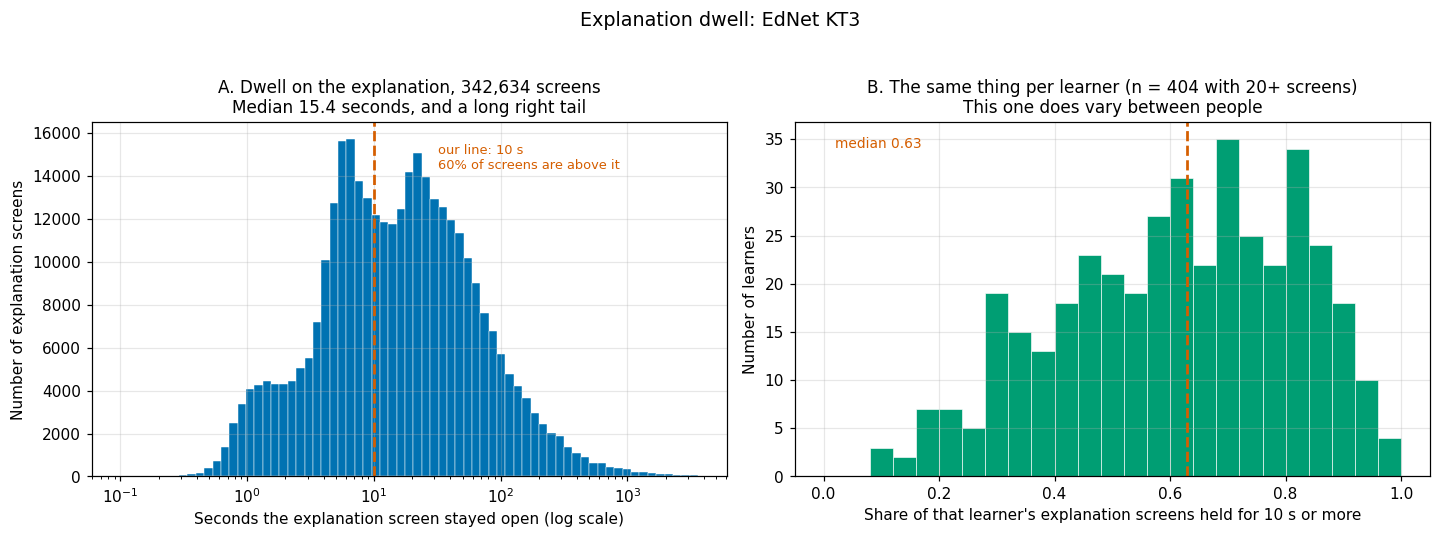

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))

ax = axes[0]
d = opened['dwell_s'][opened['dwell_s'] > 0]
bins = np.logspace(np.log10(0.1), np.log10(3600), 70)
ax.hist(d, bins=bins, color=BLUE, edgecolor='white', linewidth=0.3)
ax.axvline(STAY_SECONDS, color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(STAY_SECONDS * 3.2, ax.get_ylim()[1] * 0.94,
        'our line: %d s\n%.0f%% of screens are above it' % (STAY_SECONDS,
                                                            (opened['dwell_s'] >= STAY_SECONDS).mean() * 100),
        fontsize=8.5, color=VERMILLION, va='top')
ax.set_xscale('log')
ax.set_xlabel('Seconds the explanation screen stayed open (log scale)')
ax.set_ylabel('Number of explanation screens')
ax.set_title('A. Dwell on the explanation, 342,634 screens\nMedian 15.4 seconds, and a long right tail')

ax = axes[1]
ax.hist(enough['share_stayed'], bins=np.linspace(0, 1, 26), color=GREEN,
        edgecolor='white', linewidth=0.4)
ax.axvline(enough['share_stayed'].median(), color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(0.02, ax.get_ylim()[1] * 0.96,
        'median %.2f' % enough['share_stayed'].median(), fontsize=9, color=VERMILLION,
        va='top', ha='left')
ax.set_xlabel('Share of that learner\'s explanation screens held for %d s or more' % STAY_SECONDS)
ax.set_ylabel('Number of learners')
ax.set_title('B. The same thing per learner (n = %d with 20+ screens)\nThis one does vary between people' % len(enough))

fig.suptitle('Explanation dwell: EdNet KT3',
             fontsize=12.5, y=1.03)
plt.tight_layout()
plt.show()

**Let's look at the output.**

1. Panel A: 8.7 percent of explanation screens close within two seconds and 40.2 percent close within ten. What are some reasons a person on a phone closes a screen fast? "Did not want the help" is one of several, and it may be worth listing the others first.
2. Panel B is the first measure in this notebook with genuine spread that the app does not obviously impose: from 0.316 at the tenth percentile to 0.866 at the ninetieth. Would you put this on a dashboard? What label would the column carry, in words a tutor would read correctly?
3. The interval on the median comes from resampling **learners**, not screens. A colleague who wants to resample the 342,634 screens because it gives a tighter interval is asking for something the nesting does not allow. How would you explain that to them?
4. 96 of 500 learners are excluded from panel B, and the notebook says plainly that they are excluded by a rule. What does that do to the sentence "the typical learner stays on about 63 percent of explanations"?

### 7.1 Explanations opened by the flow against explanations opened another way

The hypothesis:

> An explanation the learner **opened themselves** should hold their attention longer than one the app **put in front of them**. Choosing help is a regulation move; being handed it is not.

Section 5 supplies the split. An explanation screen either follows a submit of the same bundle, in which case the app opened it, or it does not, in which case something else did. The cells below compare the dwell.

Because dwell varies enormously between people, the comparison is made **within each learner** and then summarized across learners, with an interval from resampling learners. **Run the two cells below.**

In [20]:
pair = (opened.groupby(['user_id', 'opened_by_the_flow'])['dwell_s']
        .agg(['median', 'size']).unstack())
pair.columns = ['median_other', 'median_flow', 'n_other', 'n_flow']
pair = pair.dropna()
pair = pair[(pair['n_flow'] >= 20) & (pair['n_other'] >= 20)]
diff = pair['median_other'] - pair['median_flow']

print('Pooled over all %s explanation screens:' % format(len(opened), ','))
print('   opened by the flow (right after that bundle\'s submit): %s screens, median %.2f s'
      % (format(int(opened['opened_by_the_flow'].sum()), ','),
         opened.loc[opened['opened_by_the_flow'], 'dwell_s'].median()))
print('   opened some other way                                : %s screens, median %.2f s'
      % (format(int((~opened['opened_by_the_flow']).sum()), ','),
         opened.loc[~opened['opened_by_the_flow'], 'dwell_s'].median()))
print()
print('WITHIN LEARNER, among the %d learners with at least 20 screens of each kind:' % len(pair))
print('   median of (other minus flow) in median dwell: %+.2f s' % diff.median())
print('   learners where "other" is longer            : %d of %d (%.1f%%)'
      % (int((diff > 0).sum()), len(diff), (diff > 0).mean() * 100))
rng = np.random.default_rng(8100)
bd = np.array([np.median(diff.values[rng.integers(0, len(diff), len(diff))]) for _ in range(4000)])
print('   bootstrap 95%% interval, resampling learners: [%+.2f, %+.2f] seconds'
      % (np.percentile(bd, 2.5), np.percentile(bd, 97.5)))
print()
print('The interval lies entirely below zero: within learner, screens not opened by the flow have')
print('a shorter median dwell than screens that follow a submit.')
print('The next cell asks what those screens are before reading that as a fact about help seeking.')

Pooled over all 342,634 explanation screens:
   opened by the flow (right after that bundle's submit): 295,035 screens, median 16.49 s
   opened some other way                                : 47,599 screens, median 8.31 s

WITHIN LEARNER, among the 258 learners with at least 20 screens of each kind:
   median of (other minus flow) in median dwell: -7.77 s
   learners where "other" is longer            : 50 of 258 (19.4%)
   bootstrap 95% interval, resampling learners: [-9.76, -5.50] seconds

The interval lies entirely below zero: within learner, screens not opened by the flow have
a shorter median dwell than screens that follow a submit.
The next cell asks what those screens are before reading that as a fact about help seeking.


Where an explanation screen comes from, and how long it stays open
                                           screens  median_dwell_s  pct_held_10s_plus  pct_of_all_screens
opened_after                                                                                             
right after submitting that bundle          295035          16.488               62.0                86.1
reopened the one just closed                 26131           6.503               40.4                 7.6
opened a different explanation               17878          12.020               53.4                 5.2
right after submitting a different bundle     1927          16.013               58.6                 0.6
right after closing a lecture                 1652          10.129               50.2                 0.5
first action in this learner's log              11          52.258               81.8                 0.0

54.9% of the screens that were NOT opened by the flow are the learner
reopening the 

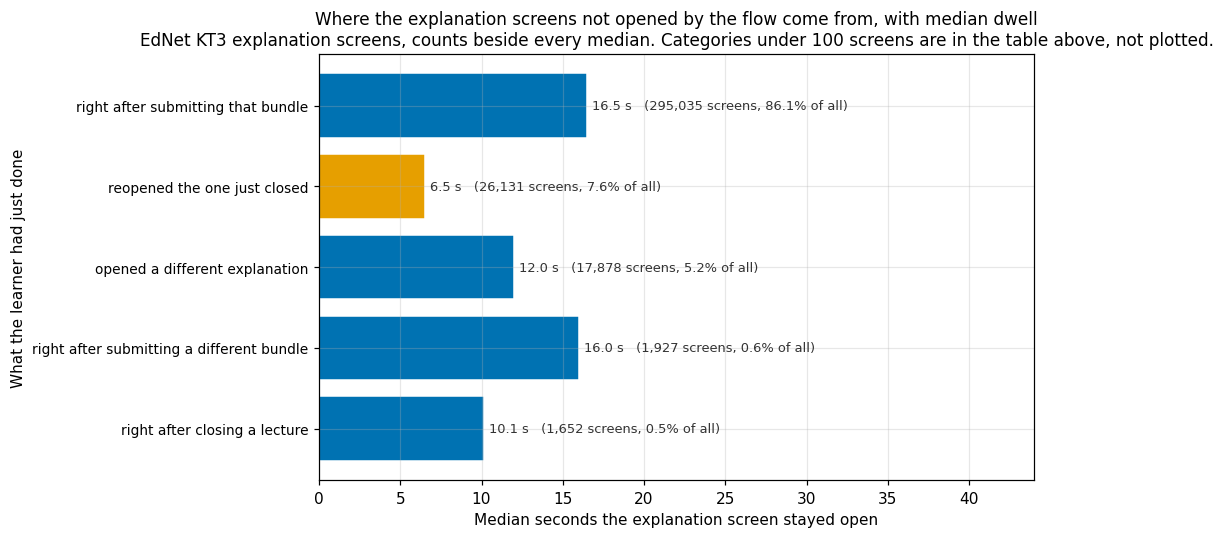

In [21]:
# Why. Split "some other way" by what the learner had just been doing.
prev_state_all = actions['event'].shift()
prev_num_all = actions['item_num'].shift()
same_prev_all = actions['user_id'] == actions['user_id'].shift()

origin = pd.Series('first action in this learner\'s log', index=actions.index)
origin[same_prev_all & (prev_state_all == 'submit_b')
       & (prev_num_all == actions['item_num'])] = 'right after submitting that bundle'
origin[same_prev_all & (prev_state_all == 'submit_b')
       & (prev_num_all != actions['item_num'])] = 'right after submitting a different bundle'
origin[same_prev_all & (prev_state_all == 'quit_e')
       & (prev_num_all == actions['item_num'])] = 'reopened the one just closed'
origin[same_prev_all & (prev_state_all == 'quit_e')
       & (prev_num_all != actions['item_num'])] = 'opened a different explanation'
origin[same_prev_all & (prev_state_all == 'quit_l')] = 'right after closing a lecture'
opened['opened_after'] = origin.reindex(opened['index']).values

breakdown = opened.groupby('opened_after').agg(
    screens=('dwell_s', 'size'),
    median_dwell_s=('dwell_s', 'median'),
    pct_held_10s_plus=('dwell_s', lambda s: round((s >= 10).mean() * 100, 1)))
breakdown['pct_of_all_screens'] = (breakdown['screens'] / len(opened) * 100).round(1)
breakdown = breakdown.sort_values('screens', ascending=False)
print('Where an explanation screen comes from, and how long it stays open')
print(breakdown.to_string())
print()
print('%.1f%% of the screens that were NOT opened by the flow are the learner'
      % (100 * breakdown.loc['reopened the one just closed', 'screens']
         / int((~opened['opened_by_the_flow']).sum())))
print('reopening the explanation they had just closed, a median of %.1f s each.'
      % breakdown.loc['reopened the one just closed', 'median_dwell_s'])
print('A screen reopened immediately after its own close and held for a median of 6.5 s is a')
print('different kind of event from a first viewing held for 16.5 s. The label "opened it')
print('themselves" was ours, not the log\'s.')

plotted = breakdown[breakdown['screens'] >= 100]
fig, ax = plt.subplots(figsize=(9.6, 5.0))
order = list(plotted.index)
pos = np.arange(len(order))
colors = [ORANGE if o == 'reopened the one just closed' else BLUE for o in order]
ax.barh(pos, plotted['median_dwell_s'], color=colors, edgecolor='white')
for i, o in enumerate(order):
    ax.text(plotted.loc[o, 'median_dwell_s'] + 0.3, i,
            '%.1f s   (%s screens, %.1f%% of all)'
            % (plotted.loc[o, 'median_dwell_s'],
               format(int(plotted.loc[o, 'screens']), ','),
               plotted.loc[o, 'pct_of_all_screens']),
            va='center', fontsize=8.5, color=BLACK)
ax.set_yticks(pos)
ax.set_yticklabels(order, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 44)
ax.set_xlabel('Median seconds the explanation screen stayed open')
ax.set_ylabel('What the learner had just done')
ax.set_title('Where the explanation screens not opened by the flow come from, with median dwell\n'
             'EdNet KT3 explanation screens, counts beside every median. '
             'Categories under 100 screens are in the table above, not plotted.')
plt.tight_layout()
plt.show()

**Let's discuss.**

1. The hypothesis, the result, and the reason each fit in a sentence. Then the question that matters: **was the hypothesis wrong, or was the operationalization wrong?** They call for different repairs.
2. `reopened the one just closed` is 26,131 screens at a median of 6.5 seconds. What are two interface explanations for a person opening and instantly reclosing the same screen? Neither of them needs a sentence about motivation.
3. The pooled comparison and the within-learner comparison agree in direction here. What would a case look like in which they **disagreed**, and which one would you report?
4. **Before a split becomes a variable.** It is worth looking at what is actually in each side of it. This notebook came close to reporting "learners who seek help engage less with it", and the available evidence points instead to reopened screens being short.

### 7.2 Time to the first answer

One more timing measure, and this one is about the answering rather than the help: the seconds between a bundle opening and the first recorded response inside it.

This is the single stretch of a KT3 log that plausibly contains reading and thinking. It is worth knowing how much of the log it is. **Run the cell below.**

Bundles with a timed first answer: 300,374 of 314,791 episodes

Seconds from the bundle opening to the first answer:
   10th percentile :      8.5 s
   25th percentile :     13.1 s
   50th percentile :     19.0 s
   75th percentile :     32.2 s
   90th percentile :     66.2 s
   99th percentile :    203.5 s
   share under 3 seconds : 0.013  (3,939 bundles)
   share over 5 minutes  : 0.0045  (1,364 bundles)

Per learner, among the 415 learners with at least 20 timed bundles:
   10th percentile of the per-learner medians :   15.3 s
   25th percentile of the per-learner medians :   17.6 s
   50th percentile of the per-learner medians :   20.1 s
   75th percentile of the per-learner medians :   23.2 s
   90th percentile of the per-learner medians :   27.6 s


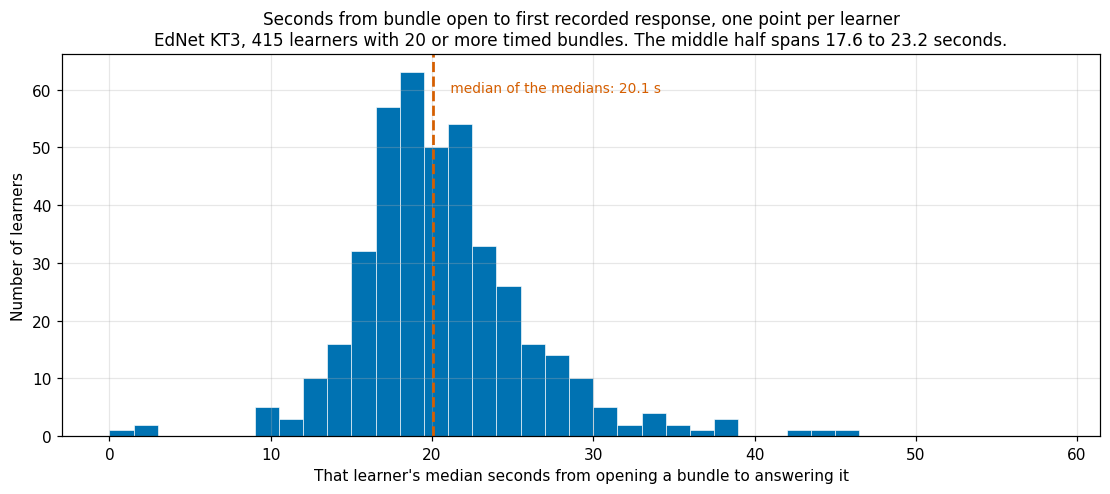

In [22]:
episode_start = inside[inside['event'] == 'enter_b'].groupby('episode')['timestamp'].first()
first_answer = inside[inside['event'] == 'respond_q'].groupby('episode')['timestamp'].first()
episode_user = inside[inside['event'] == 'enter_b'].groupby('episode')['user_id'].first()

time_to_answer = ((first_answer - episode_start) / 1000.0).dropna()
tta = pd.DataFrame({'seconds': time_to_answer})
tta['user_id'] = tta.index.map(episode_user)

print('Bundles with a timed first answer: %s of %s episodes'
      % (format(len(tta), ','), format(int(actions['episode'].max()), ',')))
print()
print('Seconds from the bundle opening to the first answer:')
for p in [10, 25, 50, 75, 90, 99]:
    print('   %2dth percentile : %8.1f s' % (p, np.percentile(tta['seconds'], p)))
print('   share under 3 seconds : %.3f  (%s bundles)'
      % ((tta['seconds'] < 3).mean(), format(int((tta['seconds'] < 3).sum()), ',')))
print('   share over 5 minutes  : %.4f  (%s bundles)'
      % ((tta['seconds'] > 300).mean(), format(int((tta['seconds'] > 300).sum()), ',')))

pl_tta = tta.groupby('user_id')['seconds'].agg(['median', 'size'])
pl_tta = pl_tta[pl_tta['size'] >= 20]
print()
print('Per learner, among the %d learners with at least 20 timed bundles:' % len(pl_tta))
for p in [10, 25, 50, 75, 90]:
    print('   %2dth percentile of the per-learner medians : %6.1f s'
          % (p, np.percentile(pl_tta['median'], p)))

fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.hist(pl_tta['median'], bins=np.arange(0, 60, 1.5), color=BLUE, edgecolor='white', linewidth=0.4)
ax.axvline(pl_tta['median'].median(), color=VERMILLION, linestyle='--', linewidth=1.8)
ax.text(pl_tta['median'].median() + 0.8, ax.get_ylim()[1] * 0.9,
        ' median of the medians: %.1f s' % pl_tta['median'].median(), fontsize=9, color=VERMILLION)
ax.set_xlabel('That learner\'s median seconds from opening a bundle to answering it')
ax.set_ylabel('Number of learners')
ax.set_title('Seconds from bundle open to first recorded response, one point per learner\n'
             'EdNet KT3, %d learners with 20 or more timed bundles. The middle half spans %.1f to %.1f seconds.'
             % (len(pl_tta), pl_tta['median'].quantile(.25), pl_tta['median'].quantile(.75)))
plt.tight_layout()
plt.show()

**Let's discuss.**

1. The middle half of learners have a median time to answer between 17.6 and 23.2 seconds. That is a **narrow** band across 415 learners with 20 or more timed bundles. What is the instrument explanation, and what is the setting explanation? Only after both is it worth asking whether it says anything about people.
2. 1.3 percent of bundles are answered within three seconds. The field has phrases for patterns like this. It calls them **"gaming the system"** and describes them as **"hint spam"**, and those phrases appear in the literature. Each phrase names a motive that no timestamp can see. What was recorded is **an answer arriving within three seconds of the question appearing**. What are three things that produce such a row? At least two of them can be properties of the item or the app.
3. Comparing the spread here with the spread in the explanation dwell chart, one of these measures separates people and one does not. Which would you build a study on, and what does the other one still tell you?
4. Returning to Winne: of everything computed today, which measure would you put forward as evidence about **self-regulation** rather than about activity, and what is the single strongest objection to that choice?

*Connecting to the readings.* Viberg, Khalil and Baars (2020) reviewed 54 empirical studies of learning analytics for self-regulated learning published between 2011 and 2019 and found that most concentrated on the forethought and performance phases with much less attention to reflection, and that the work was conducted mainly to measure self-regulated learning rather than to support it.

### Your turn 4

Section 7 rests on a threshold nobody chose on evidence: **how many seconds counts as staying on the explanation**. Ten was the notebook's pick.

This cell ships with **5 seconds**, deliberately different from the notebook's 10.

In [23]:
# TODO: change this and rerun. Try 2, then 5, then 10, then 30.
MY_STAY_SECONDS = 5

mine_stay = opened.groupby('user_id').agg(
    screens=('dwell_s', 'size'),
    share=('dwell_s', lambda s: (s >= MY_STAY_SECONDS).mean()))
mine_stay = mine_stay[mine_stay['screens'] >= 20]

print('Your line: a screen "stayed on" if it was held for %d seconds or more.' % MY_STAY_SECONDS)
print("The notebook's line: %d seconds." % STAY_SECONDS)
print()
print('                                                       yours    notebook')
print('learners summarized (20+ screens)                  %9d %11d' % (len(mine_stay), len(enough)))
print('share of ALL screens above the line                %9.3f %11.3f'
      % ((opened['dwell_s'] >= MY_STAY_SECONDS).mean(), (opened['dwell_s'] >= STAY_SECONDS).mean()))
print('median per-learner share                           %9.3f %11.3f'
      % (mine_stay['share'].median(), enough['share_stayed'].median()))
print('learners in the bottom decile on this measure      %9d %11d'
      % (int((mine_stay['share'] <= mine_stay['share'].quantile(.10)).sum()),
         int((enough['share_stayed'] <= enough['share_stayed'].quantile(.10)).sum())))

bottom_mine = set(mine_stay.index[mine_stay['share'] <= mine_stay['share'].quantile(.10)])
bottom_nb = set(enough.index[enough['share_stayed'] <= enough['share_stayed'].quantile(.10)])
print()
print('Learners in the bottom decile under BOTH lines : %d' % len(bottom_mine & bottom_nb))
print('Learners in the bottom decile under only ONE   : %d'
      % len(bottom_mine.symmetric_difference(bottom_nb)))
print()
print('Those are learners whose label depends on the threshold. Please write down what a report')
print('using this measure would need to state about the threshold before describing them.')

Your line: a screen "stayed on" if it was held for 5 seconds or more.
The notebook's line: 10 seconds.

                                                       yours    notebook
learners summarized (20+ screens)                        404         404
share of ALL screens above the line                    0.789       0.598
median per-learner share                               0.887       0.629
learners in the bottom decile on this measure             41          41

Learners in the bottom decile under BOTH lines : 19
Learners in the bottom decile under only ONE   : 44

Those are learners whose label depends on the threshold. Please write down what a report
using this measure would need to state about the threshold before describing them.


## Reflection

Written answers to at least two of these are the basis of the discussion hour. Two or three sentences each is plenty.

**On Winne (2022), "Learning analytics for self-regulated learning."**
Winne argues that self-regulated learning is not directly observable and that traces are what it leaves behind. This week offered 1,893,105 logged actions and no answer key. Which measure built here comes closest to evidence about regulation, and what would have to be true of the Santa interface for that measure to mean what we would want it to mean? Then the harder version: about one of the 42 learners with no recorded explanation event, what has actually been learned?

**On Zhang, Borchers, and Barany (2024), "Studying the interplay of self-regulated learning cycles and scaffolding through ordered network analysis across three tutoring systems."**
Their analysis compares regulation processes across three tutoring systems that differ in how much they scaffold, using think-aloud data coded for self-regulated learning. Section 5 of this notebook found that Santa's central piece of scaffolding, the explanation, is delivered rather than requested, at a speed that depends on the device. Using that, one could argue that the scaffolding here is shaping the regulation we measured rather than revealing it, or that the distinction cannot be drawn from a log of this kind. Either way, what would a comparison across three systems have to hold constant for it to be fair?

**On Viberg, Khalil, and Baars (2020), "Self-regulated learning and learning analytics in online learning environments."**
Their review of 54 studies concludes that this literature has been used mainly to measure self-regulated learning rather than to support it. Turning that on today: four candidate measures were built here, the action profile, bundles per sitting, explanation dwell, and time to first answer. How would you rank them from "activity with a nicer name" to "defensible evidence about regulation", and what is the case for the ordering? At least one of them belongs at the bottom for a reason that fits in a sentence.

**Across the three, and across the course.**
In Week 3, part of what the fairness audit found traced to the feature set: the redesigned model made 474 fewer false positives than the activity-only model (164 against 638) and reached accuracy 0.795 against 0.735, though the audit could not show that the flag gradient across deprivation deciles flattened. Today the notebook made at least six choices: thirty minutes for a session, ten seconds for staying on an explanation, ten answers per question for the concentration comparison, twenty screens to summarize a learner, which two of the seven events to leave out of the profile, and which comparisons to make within learner rather than across rows. Which one seems most consequential and least well supported, and what evidence would settle it?

Then a seventh, which is not a modeling choice at all. Section 5 showed that "number of explanations opened" ranks learners at Spearman 0.995 with "amount of app use". If a vendor shipped that as an engagement metric, would they be lying?

### A question for our guest

Conrad Borchers joins us this week and is a coauthor of the Zhang, Borchers, and Barany reading. The preparation block before the break is where we collect and sharpen questions together, so it is worth arriving with one on paper.

The draft below came out of Section 3: every session statistic in this notebook moved by a factor of two or three when the gap rule moved, and ordered network analysis rests on a window choice of the same kind. Their paper reports a moving stanza with a window length of four, chosen from the four-stage model of self-regulated learning, and notes that windows of five and six produced no substantial change in the models. So:

> "Ordered network analysis connects actions inside a window the analyst chooses. Your paper reports a window of four and a check at five and six. When regulation cycles are compared across three systems whose interfaces pace their users differently, how far does that kind of check go toward keeping the window from doing the comparing, and what else would you want to see reported alongside it?"

## Before we meet again

**There is nothing from this notebook to upload to Canvas.** Week 7 has no mini project and nothing here is collected. The next Canvas deliverable is Mini Project 4, which launches in class in Week 8; the assignment page carries its deadline.

Checklist:

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart session and run all**).
- [ ] I can state, from memory, **what one row of EdNet KT3 is** and **what is not in the file**.
- [ ] I can explain the **explanation artifact** to somebody who has not read the notebook: why "number of explanations opened" behaves as a volume measure, and what the 0.077 second median has to do with it.
- [ ] If I worked Section 6, I can explain the **repeat answer artifact**: why an accuracy comparison between answers given with and without help would partly have measured a logging convention.
- [ ] I changed at least one value in a **Your turn** cell and noticed what moved, and ideally something that did **not** move.
- [ ] I have written answers to at least two Reflection prompts.
- [ ] I have one question written down for Conrad Borchers.
- [ ] I remember that this file is **CC BY-NC 4.0**: attribution to Choi and colleagues (2020), non-commercial use only, and nothing built on it leaves this course.

**A note on AI use.** AI assistance is permitted in designated activities and must be documented; undisclosed use is an Honor Code violation. There is no submission this week, so there is nothing to log today. The moment any of this code, or any AI conversation about it, makes its way into a mini project or your course research project, the full policy applies: the AI interaction log goes in a Word file attached to the Canvas AI Reflection submission, and the four reflection answers go in the Canvas text box.

**Looking ahead.** Week 8 is Wednesday, October 14, where Mini Project 4 launches in class.

## Going further (optional)

Everything below is optional. These are worked versions of the four **Your turn** cells.

### Going further 1: several learners at once

A handful of learners side by side makes the point that most profile columns vary little across learners, and one varies more.

In [24]:
SOME_LEARNERS = list(counts.sum(axis=1).sort_values(ascending=False).index[:3]) + ['u170']

side = (share.loc[SOME_LEARNERS].round(1).T)
side.index = [LABEL[e] for e in side.index]
side['class median'] = share.median().round(1).values
print('Percent of each learner\'s own events (with the class median in the last column)')
print(side.to_string())
print()
print('And the same learners in raw counts, because a percentage of 40,000 events and a')
print('percentage of 400 are not the same kind of statement:')
raw = counts.loc[SOME_LEARNERS].T
raw.index = [LABEL[e] for e in raw.index]
print(raw.to_string())
print()
spread = share.std().round(2)
print('Standard deviation across the 500 learners, by event:')
for e in EVENTS:
    print('   %-22s %5.2f percentage points' % (LABEL[e], spread[e]))
print()
print('The explanation column has %.1f times the spread of the bundle-opening column.'
      % (spread['enter_e'] / spread['enter_b']))
print('The other columns vary far less across learners.')

Percent of each learner's own events (with the class median in the last column)
user_id              u226  u371  u493  u170  class median
opened a bundle       5.2  18.9  20.1  22.3          23.4
answered a question  82.9  30.9  34.3  29.9          29.8
submitted a bundle    5.2  18.9  20.1  22.3          23.4
explanation opened    6.7  31.1  24.4  18.6          22.3
opened a lecture      0.1   0.2   1.0   6.9           0.8

And the same learners in raw counts, because a percentage of 40,000 events and a
percentage of 400 are not the same kind of statement:
user_id               u226  u371  u493  u170
opened a bundle       2562  5545  5601    71
answered a question  41071  9051  9534    95
submitted a bundle    2562  5545  5601    71
explanation opened    3308  9138  6784    59
opened a lecture        53    59   285    22

Standard deviation across the 500 learners, by event:
   opened a bundle         4.28 percentage points
   answered a question     7.25 percentage points
   submitte

### Going further 2: the session rule across a range of thresholds

One threshold at a time is fine for exploring. For an argument the whole curve is better, because a reader needs to know whether a result sits on a plateau or on a slope.

           sessions  bundles per sitting  minutes per sitting  sessions per learner
gap (min)                                                                          
1            171183                 1.00                 0.72                 117.0
2             93403                 2.00                 2.33                  71.0
5             48578                 5.00                 6.54                  37.0
10            33420                 7.00                10.59                  27.0
15            28852                 7.75                13.02                  24.0
20            26431                 8.00                14.23                  22.0
30            23810                 8.75                16.02                  19.0
45            21674                 9.00                17.86                  19.0
60            20426                10.00                19.28                  17.5
90            18703                10.00                20.61               

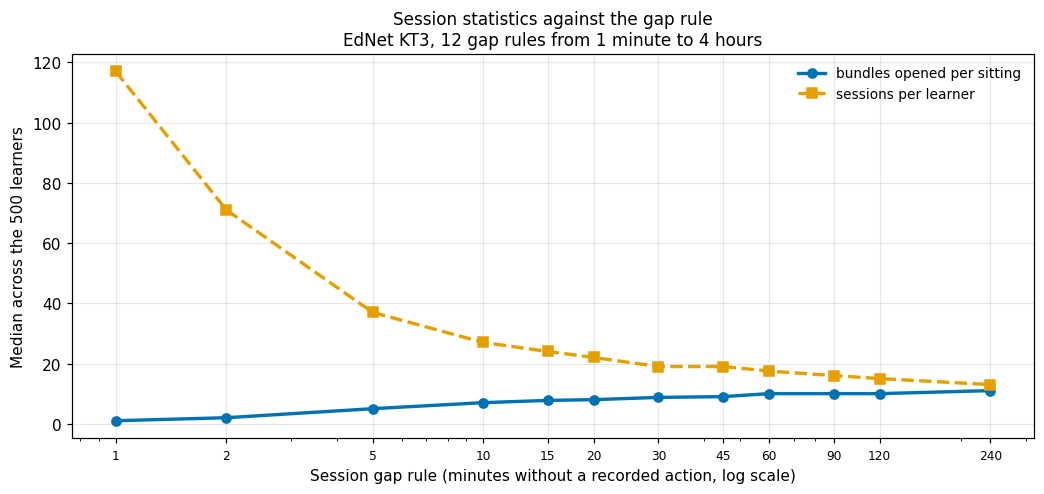

In [25]:
sweep = []
for m in [1, 2, 5, 10, 15, 20, 30, 45, 60, 90, 120, 240]:
    _, s = sessionise(m)
    pl = s.groupby('user_id').agg(n=('n_actions', 'size'), b=('bundles', 'median'),
                                  mi=('minutes', 'median'))
    sweep.append({'gap (min)': m, 'sessions': len(s),
                  'bundles per sitting': pl['b'].median(),
                  'minutes per sitting': round(pl['mi'].median(), 2),
                  'sessions per learner': pl['n'].median()})
sweep = pd.DataFrame(sweep).set_index('gap (min)')
print(sweep.to_string())
print()
print('The "bundles per sitting" column is the one to read down. It is flat at 10.0 from 60 to')
print('120 minutes, because per-learner medians take half-integer values, while the minutes column')
print('keeps rising through the same range (19.28, 20.61, 22.75); no rule gives a stable pair of')
print('statistics. A session statistic from this file is reported with its rule attached.')

fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(sweep.index, sweep['bundles per sitting'], marker='o', color=BLUE, linewidth=2.2,
        label='bundles opened per sitting')
ax.plot(sweep.index, sweep['sessions per learner'], marker='s', color=ORANGE, linewidth=2.2,
        linestyle='--', label='sessions per learner')
ax.set_xscale('log')
ax.set_xticks(sweep.index)
ax.set_xticklabels([str(v) for v in sweep.index], fontsize=8)
ax.set_xlabel('Session gap rule (minutes without a recorded action, log scale)')
ax.set_ylabel('Median across the 500 learners')
ax.set_title('Session statistics against the gap rule\n'
             'EdNet KT3, 12 gap rules from 1 minute to 4 hours')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### Going further 3: does the concentration finding survive every threshold?

Sweeping the minimum-answers threshold trades the number of questions against the noise in each one. A finding that holds across the sweep is a different kind of claim from one that does not.

One thing to hold in mind while reading the sweep: every row of it is an **unmatched** comparison, so every difference in it carries the sample-size inflation that Section 6 estimated and corrected for. The sweep shows how the comparison behaves as the filter tightens. It does not remove the bias, and neither does raising the threshold, because the bar applies to both conditions separately and the post-explanation side stays the smaller of the two.

In [26]:
rows = []
for m in [5, 10, 15, 20, 25, 30, 40, 50]:
    a = modal_share_at(first_exposure, m)
    b = modal_share_at(after_shown, m)
    qq = a.index.intersection(b.index)
    if len(qq) < 3:
        rows.append({'min answers': m, 'questions': len(qq), 'first exposure': np.nan,
                     'after explanation': np.nan, 'difference': np.nan, '% rising': np.nan})
        continue
    d = b[qq] - a[qq]
    rows.append({'min answers': m, 'questions': len(qq),
                 'first exposure': round(a[qq].median(), 3),
                 'after explanation': round(b[qq].median(), 3),
                 'difference': round(d.median(), 3),
                 '% rising': round((d > 0).mean() * 100, 1)})
print(pd.DataFrame(rows).set_index('min answers').to_string())
print()
print('The difference rises from 5 to 30 and falls at 40 and 50, where only 39 and 12 questions')
print('remain. Stricter thresholds keep the questions that many learners answered a second time,')
print('so the sweep describes which questions survive the filter rather than testing robustness.')

             questions  first exposure  after explanation  difference  % rising
min answers                                                                    
5                 3295           0.636              0.789       0.124      77.2
10                1241           0.587              0.750       0.142      83.8
15                 611           0.562              0.745       0.155      88.1
20                 324           0.538              0.739       0.179      89.5
25                 190           0.523              0.725       0.197      89.5
30                 104           0.485              0.708       0.221      90.4
40                  39           0.481              0.709       0.219      84.6
50                  12           0.500              0.701       0.198      75.0

The difference rises from 5 to 30 and falls at 40 and 50, where only 39 and 12 questions
remain. Stricter thresholds keep the questions that many learners answered a second time,
so the sweep describ

### Going further 4: how much of the bottom decile is the threshold?

How stable is membership of the bottom decile across every defensible line?

Learners in the bottom decile of "share of explanations stayed on", by threshold:
    2 s : 41 learners
    3 s : 41 learners
    5 s : 41 learners
   10 s : 41 learners
   15 s : 42 learners
   20 s : 41 learners
   30 s : 41 learners

In the bottom decile under EVERY threshold : 5 learners
In the bottom decile under AT LEAST ONE    : 85 learners
So 80 of the 85 people who could ever be labeled are labeled by the threshold
rather than by anything stable about their record. That is 94% of them.


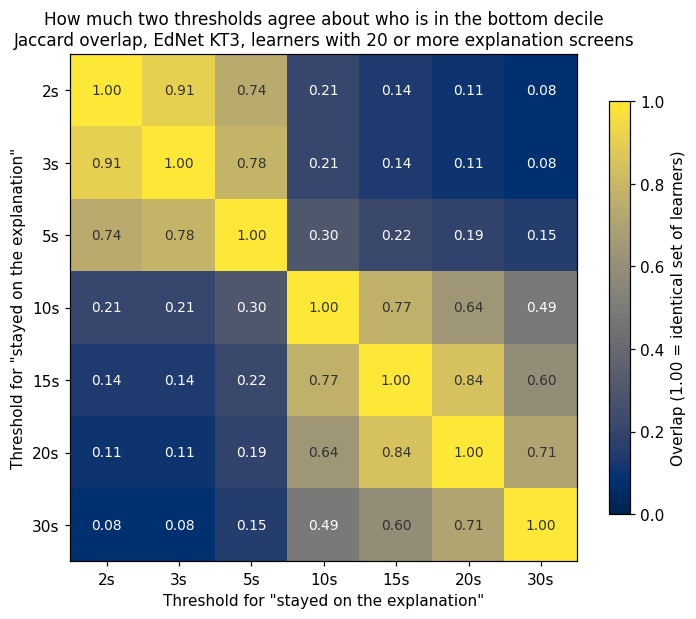

In [27]:
lines = [2, 3, 5, 10, 15, 20, 30]
members = {}
for t in lines:
    s = opened.groupby('user_id').agg(screens=('dwell_s', 'size'),
                                      share=('dwell_s', lambda x: (x >= t).mean()))
    s = s[s['screens'] >= 20]
    members[t] = set(s.index[s['share'] <= s['share'].quantile(.10)])

print('Learners in the bottom decile of "share of explanations stayed on", by threshold:')
for t in lines:
    print('   %2d s : %d learners' % (t, len(members[t])))
print()
always = set.intersection(*members.values())
ever = set.union(*members.values())
print('In the bottom decile under EVERY threshold : %d learners' % len(always))
print('In the bottom decile under AT LEAST ONE    : %d learners' % len(ever))
print('So %d of the %d people who could ever be labeled are labeled by the threshold'
      % (len(ever) - len(always), len(ever)))
print('rather than by anything stable about their record. That is %.0f%% of them.'
      % (100 * (len(ever) - len(always)) / len(ever)))

overlap = pd.DataFrame(index=lines, columns=lines, dtype=float)
for a in lines:
    for b in lines:
        overlap.loc[a, b] = len(members[a] & members[b]) / len(members[a] | members[b])
fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(overlap.values.astype(float), cmap='cividis', vmin=0, vmax=1)
ax.set_xticks(range(len(lines)))
ax.set_xticklabels(['%ds' % t for t in lines])
ax.set_yticks(range(len(lines)))
ax.set_yticklabels(['%ds' % t for t in lines])
for i in range(len(lines)):
    for j in range(len(lines)):
        v = overlap.values[i, j]
        ax.text(j, i, '%.2f' % v, ha='center', va='center', fontsize=9,
                color='white' if v < 0.55 else BLACK)
ax.set_xlabel('Threshold for "stayed on the explanation"')
ax.set_ylabel('Threshold for "stayed on the explanation"')
ax.set_title('How much two thresholds agree about who is in the bottom decile\n'
             'Jaccard overlap, EdNet KT3, learners with 20 or more explanation screens')
fig.colorbar(im, ax=ax, shrink=0.8, label='Overlap (1.00 = identical set of learners)')
ax.grid(False)
plt.tight_layout()
plt.show()

---

*EDIS 8100: Teaching and Learning Analytics. Course design by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development.*

*Data: EdNet KT3, a 500-user extract. Choi, Y., Lee, Y., Shin, D., Cho, J., Park, S., Lee, S., Baek, J., Bae, C., Kim, B., & Heo, J. (2020). EdNet: A large-scale hierarchical dataset in education. In* Artificial intelligence in education (AIED 2020), *Lecture Notes in Computer Science 12164 (pp. 69-73). Springer. Licensed CC BY-NC 4.0: attribution required, non-commercial use only.*